<a href="https://colab.research.google.com/github/YonghwanYim/CMAPSS-Experiments/blob/main/ML_Exp_2_failure_probability_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning + RL
(NASA C-MAPSS dataset)

**2023.12.26 Meeting**

Directed Loss function 추가 후 실험.

# Data Handling

Connect with Google Drive

In [159]:
from google.colab import drive
drive.mount('content')

Drive already mounted at content; to attempt to forcibly remount, call drive.mount("content", force_remount=True).


Importing libraries

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.metrics import mean_squared_error, r2_score
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import random
import warnings
np.random.seed(34)
warnings.filterwarnings('ignore')

Defining features names

In [161]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names

In [162]:
dftrain = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD001_1_70.txt',sep='\s+',header=None,index_col=False,names=col_names)
dfvalid = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD001_71_100.txt',sep='\s+',header=None,index_col=False,names=col_names)
dffull_data = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD001.txt',sep='\s+',header=None,index_col=False,names=col_names)
# y_valid : A vector of true Remaining Useful Life (RUL) values for the test data.
# y_valid = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/RUL_FD001.txt',sep='\s+',header=None,index_col=False,names=['RUL'])
# dfvalid.shape

특정 확률만큼 랜덤 샘플 추출 (관측 확률을 반영).


In [163]:
N = 10                  # number of sample.
obs_probability = 0.1  # 관측확률 : 0.1이면 10% 확률로 관측 가능하니 나머지 데이터 90%를 날리는 것을 의미함.

# 샘플링 결과 저장할 list 초기화
sampled_data_list = []

# 반복문을 통해 N번의 샘플링 수행
# random_state는 재현 가능성을 위해 사용되는 시드. 동일 시드 = 동일 샘플
for i in range(N):
    # 샘플링 수행
    sampled_dftrain = dftrain.sample(frac=obs_probability, random_state=i)
    sampled_dfvalid = dfvalid.sample(frac=obs_probability, random_state=i)
    sampled_dffull_data = dffull_data.sample(frac=obs_probability, random_state=i)

    # 데이터 정렬
    sampled_dftrain = sampled_dftrain.sort_values(by=['unit_number', 'time_cycles'])
    sampled_dfvalid = sampled_dfvalid.sort_values(by=['unit_number', 'time_cycles'])
    sampled_dffull_data = sampled_dffull_data.sort_values(by=['unit_number', 'time_cycles'])

    # 샘플링 결과를 리스트에 추가
    sampled_data_list.append((sampled_dftrain.copy(), sampled_dfvalid.copy(), sampled_dffull_data.copy()))

sampled dataset 확인

In [164]:
for i, (sampled_dftrain, sampled_dfvalid, sampled_dffull_data) in enumerate(sampled_data_list, start=1):
    print(f"Sampled Data {i}:")
    print("Sampled Train Data:")
    print(sampled_dftrain.head())
    print("Sampled Valid Data:")
    print(sampled_dfvalid.head())
    print("Sampled Full Data:")
    print(sampled_dffull_data.head())

Sampled Data 1:
Sampled Train Data:
    unit_number  time_cycles  setting_1  setting_2  setting_3     s_1     s_2  \
33            1           34     0.0015    -0.0001      100.0  518.67  642.54   
37            1           38    -0.0018    -0.0002      100.0  518.67  641.93   
44            1           45    -0.0013    -0.0000      100.0  518.67  642.53   
45            1           46     0.0003     0.0001      100.0  518.67  642.43   
48            1           49    -0.0014     0.0005      100.0  518.67  642.23   

        s_3      s_4    s_5  ...    s_12     s_13     s_14    s_15  s_16  \
33  1581.47  1400.48  14.62  ...  521.70  2388.09  8126.61  8.4349  0.03   
37  1589.60  1399.50  14.62  ...  522.42  2388.08  8136.61  8.4158  0.03   
44  1582.42  1399.16  14.62  ...  521.73  2388.05  8128.31  8.4099  0.03   
45  1588.29  1401.27  14.62  ...  522.02  2388.08  8128.71  8.3977  0.03   
48  1584.35  1397.76  14.62  ...  521.37  2388.04  8135.48  8.4151  0.03   

    s_17  s_18   s_1

**1번 샘플에 대해 코드 실행.**

In [165]:
train = sampled_data_list[0][0].copy()
valid = sampled_data_list[0][1].copy()
full_data = sampled_data_list[0][2].copy()

Add RUL column to the data

RUL corresponds to the remaining time cycles for each unit before it falls.

In [166]:
def add_RUL_column(df):
    train_grouped_by_unit = df.groupby(by='unit_number')
    max_time_cycles = train_grouped_by_unit['time_cycles'].max()
    merged = df.merge(max_time_cycles.to_frame(name='max_time_cycle'), left_on='unit_number',right_index=True)
    merged["RUL"] = merged["max_time_cycle"] - merged['time_cycles']
    merged = merged.drop("max_time_cycle", axis=1)
    return merged

In [167]:
train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

In [168]:
train

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
33,1,34,0.0015,-0.0001,100.0,518.67,642.54,1581.47,1400.48,14.62,...,2388.09,8126.61,8.4349,0.03,392,2388,100.0,38.81,23.3092,155
37,1,38,-0.0018,-0.0002,100.0,518.67,641.93,1589.60,1399.50,14.62,...,2388.08,8136.61,8.4158,0.03,392,2388,100.0,39.06,23.4768,151
44,1,45,-0.0013,-0.0000,100.0,518.67,642.53,1582.42,1399.16,14.62,...,2388.05,8128.31,8.4099,0.03,393,2388,100.0,38.79,23.3943,144
45,1,46,0.0003,0.0001,100.0,518.67,642.43,1588.29,1401.27,14.62,...,2388.08,8128.71,8.3977,0.03,393,2388,100.0,38.93,23.3745,143
48,1,49,-0.0014,0.0005,100.0,518.67,642.23,1584.35,1397.76,14.62,...,2388.04,8135.48,8.4151,0.03,392,2388,100.0,39.06,23.4498,140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14062,70,70,0.0014,-0.0000,100.0,518.67,642.35,1588.16,1411.22,14.62,...,2388.09,8152.06,8.4603,0.03,393,2388,100.0,38.82,23.2694,57
14077,70,85,-0.0019,-0.0004,100.0,518.67,642.58,1596.02,1409.61,14.62,...,2388.10,8141.18,8.4337,0.03,393,2388,100.0,38.83,23.1555,42
14101,70,109,-0.0007,0.0003,100.0,518.67,642.60,1591.01,1417.75,14.62,...,2388.15,8150.51,8.4672,0.03,395,2388,100.0,38.66,23.1991,18
14117,70,125,-0.0001,-0.0000,100.0,518.67,643.51,1597.66,1426.85,14.62,...,2388.12,8160.11,8.5542,0.03,395,2388,100.0,38.56,23.1302,2


In [169]:
Sensor_dictionary={}
dict_list=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
i=1
for x in dict_list :
    Sensor_dictionary['s_'+str(i)]=x
    i+=1
Sensor_dictionary

{'s_1': '(Fan inlet temperature) (◦R)',
 's_2': '(LPC outlet temperature) (◦R)',
 's_3': '(HPC outlet temperature) (◦R)',
 's_4': '(LPT outlet temperature) (◦R)',
 's_5': '(Fan inlet Pressure) (psia)',
 's_6': '(bypass-duct pressure) (psia)',
 's_7': '(HPC outlet pressure) (psia)',
 's_8': '(Physical fan speed) (rpm)',
 's_9': '(Physical core speed) (rpm)',
 's_10': '(Engine pressure ratio(P50/P2)',
 's_11': '(HPC outlet Static pressure) (psia)',
 's_12': '(Ratio of fuel flow to Ps30) (pps/psia)',
 's_13': '(Corrected fan speed) (rpm)',
 's_14': '(Corrected core speed) (rpm)',
 's_15': '(Bypass Ratio) ',
 's_16': '(Burner fuel-air ratio)',
 's_17': '(Bleed Enthalpy)',
 's_18': '(Required fan speed)',
 's_19': '(Required fan conversion speed)',
 's_20': '(High-pressure turbines Cool air flow)',
 's_21': '(Low-pressure turbines Cool air flow)'}

Plotting the evolution of features (sensors) along with the evolution with RUL

In [170]:
def plot_signal(df, Sensor_dic, signal_name):
    plt.figure(figsize=(13,5))
    for i in df['unit_number'].unique():
      #plt.plot('RUL', signal_name, data=df[df['unit_number']==i].rolling(10).mean())
       if (i % 5 == 0):   #For a better visualisation, we plot the sensors signals of 10 units only (data : FD001)
           plt.plot('RUL', signal_name, data=df[df['unit_number']==i].rolling(10).mean())

    plt.xlim(250, 0)  # reverse the x-axis so RUL counts down to zero  # xlim() : range of x-axis
    plt.xticks(np.arange(0, 300, 25))
    plt.ylabel(Sensor_dic[signal_name])
    plt.xlabel('Remaining Useful Life')
    plt.show()

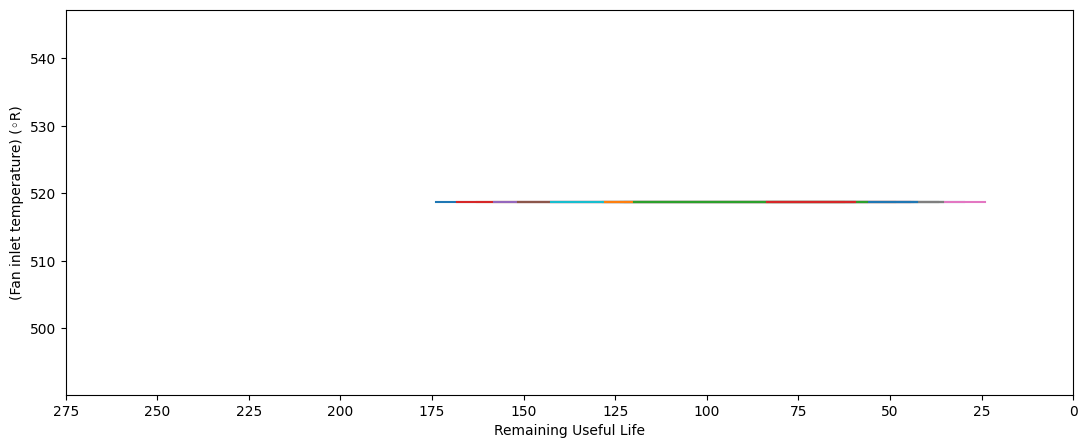

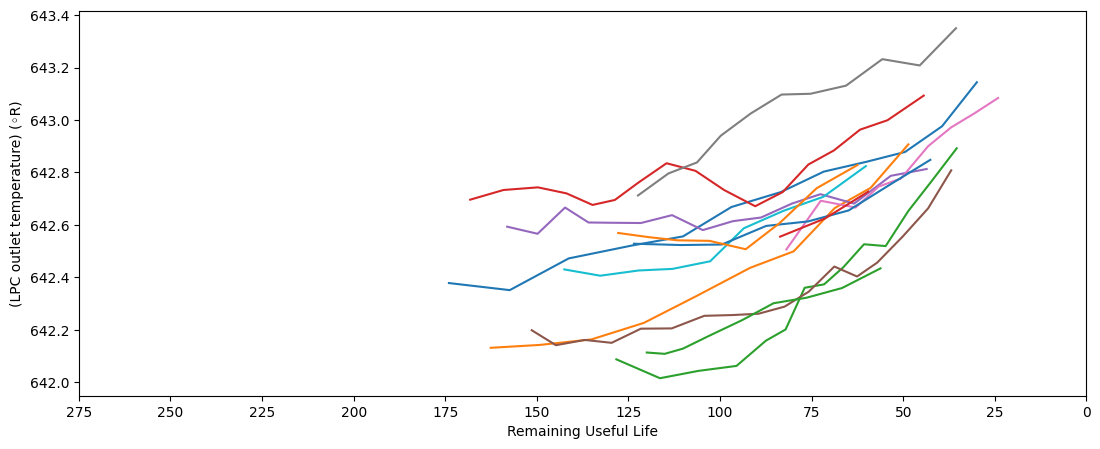

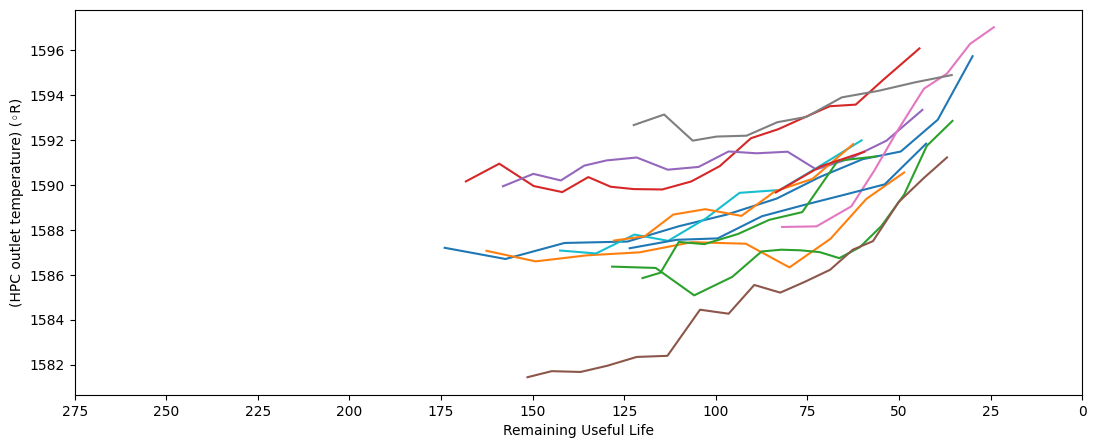

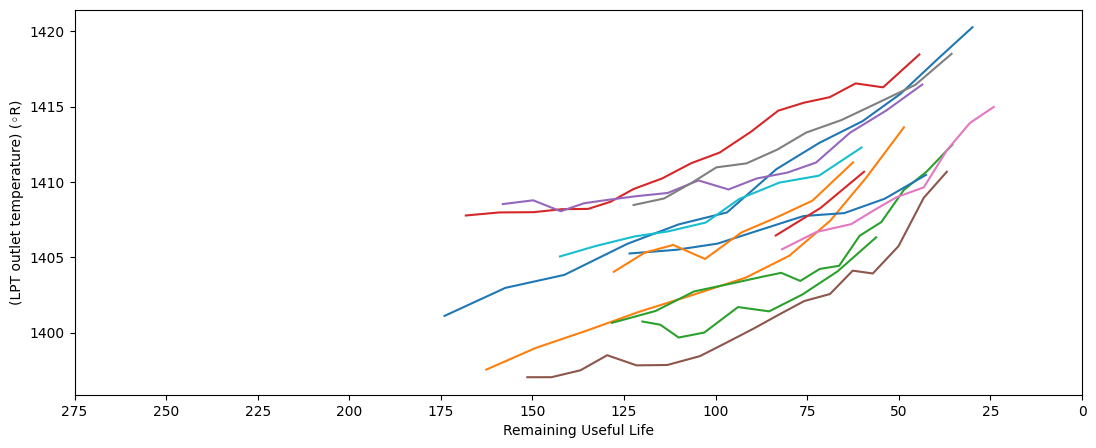

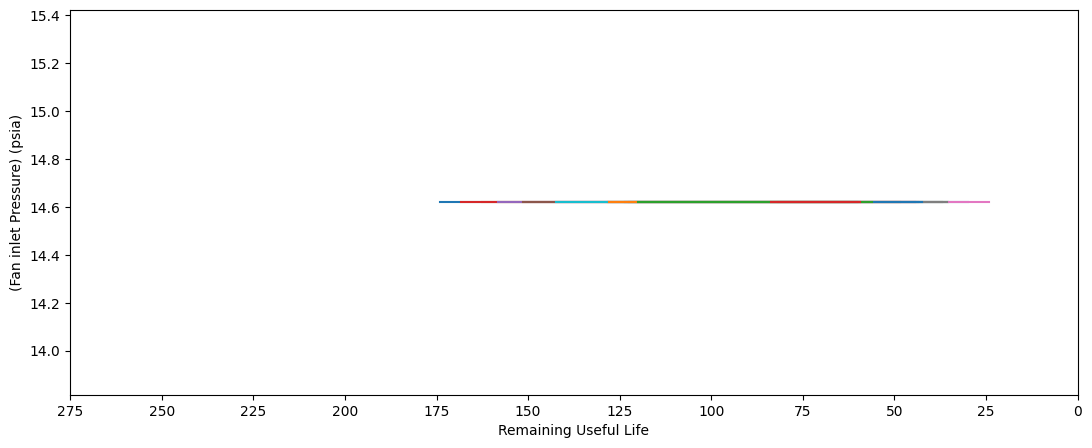

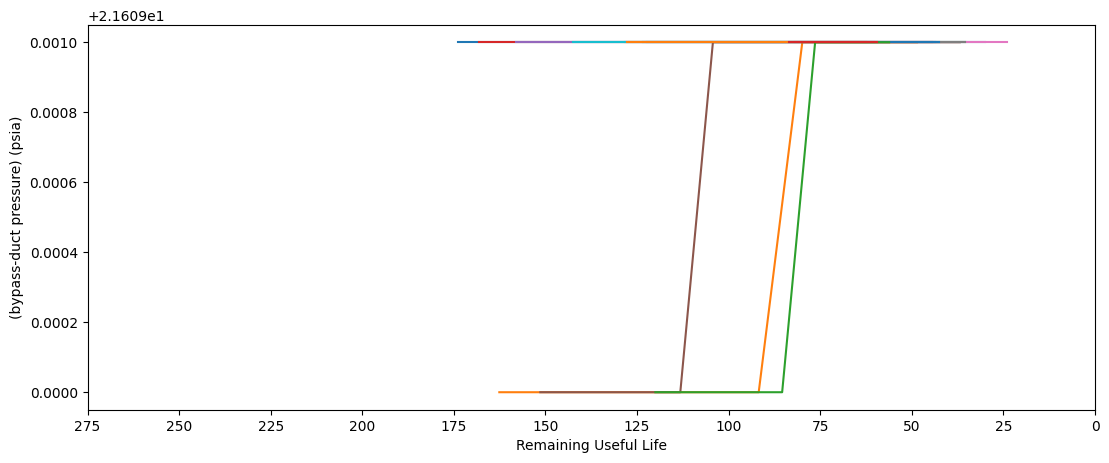

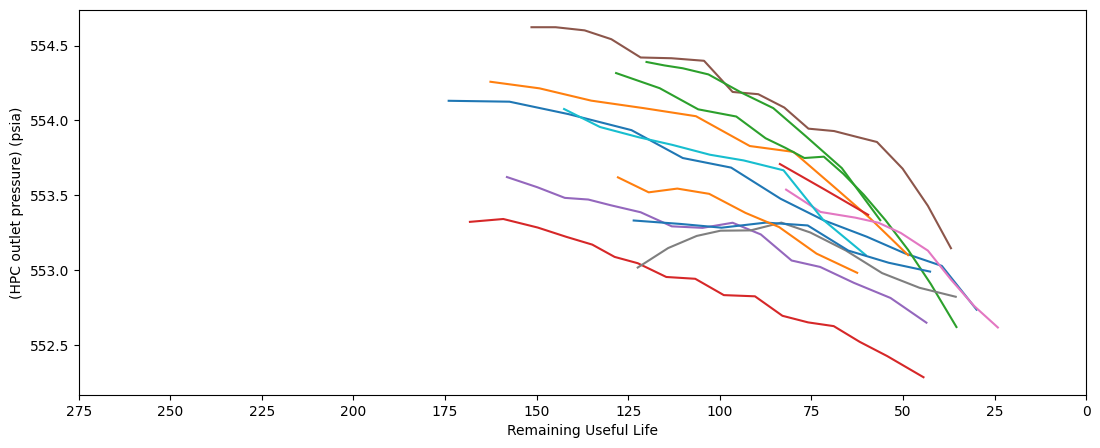

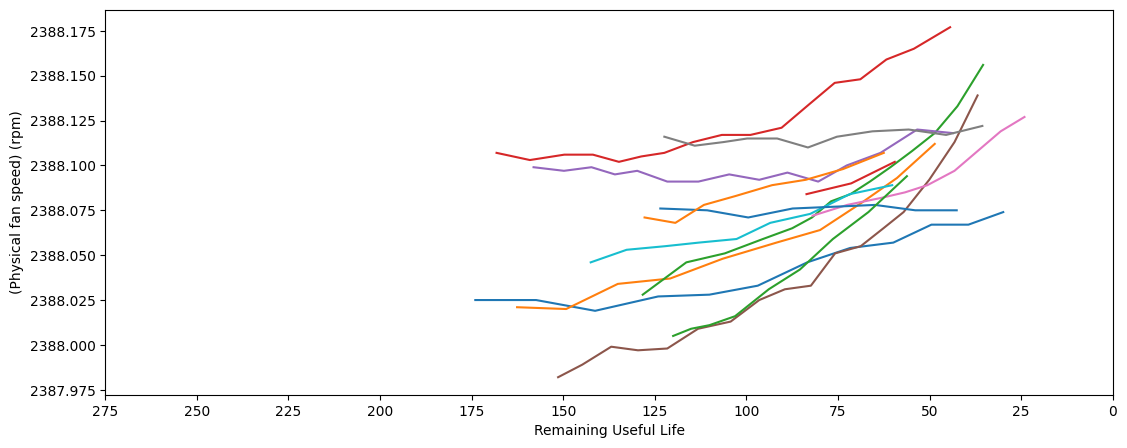

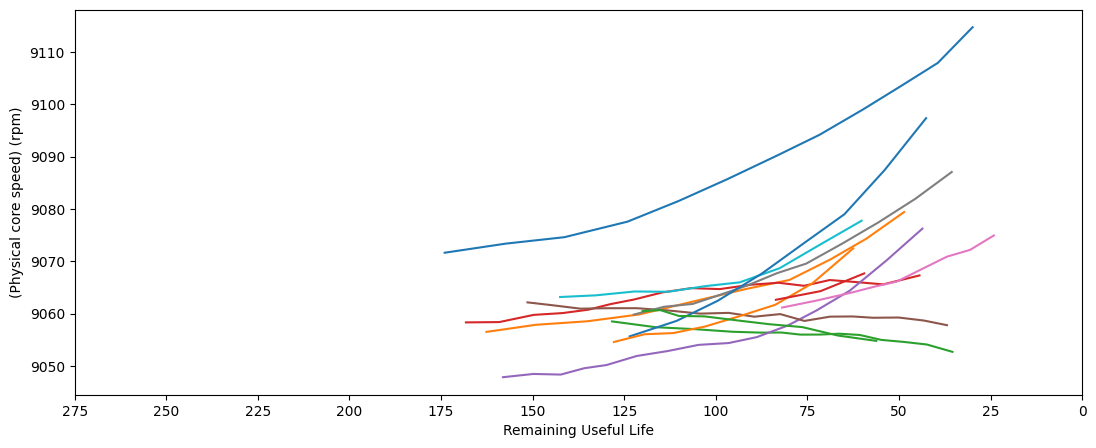

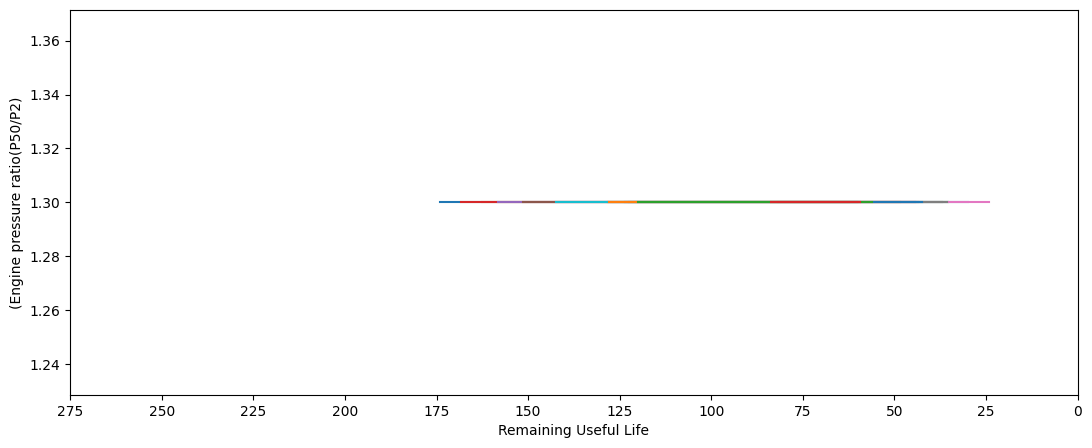

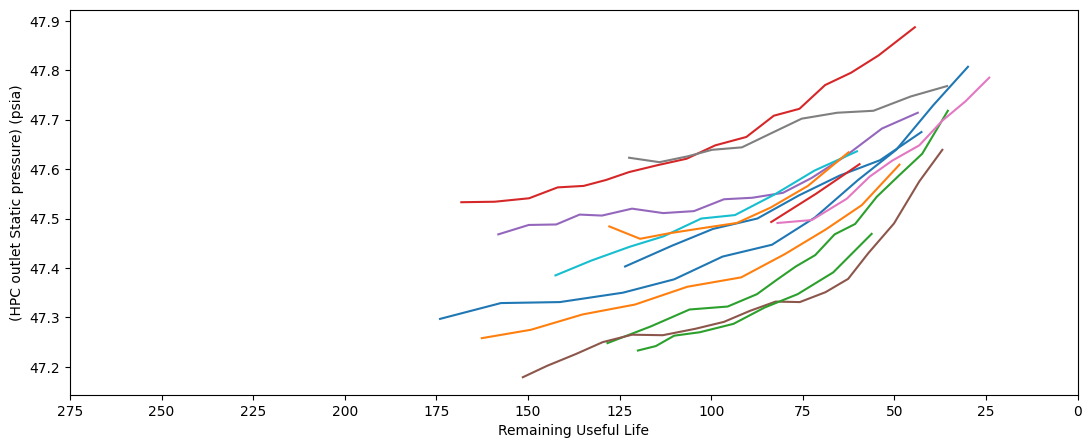

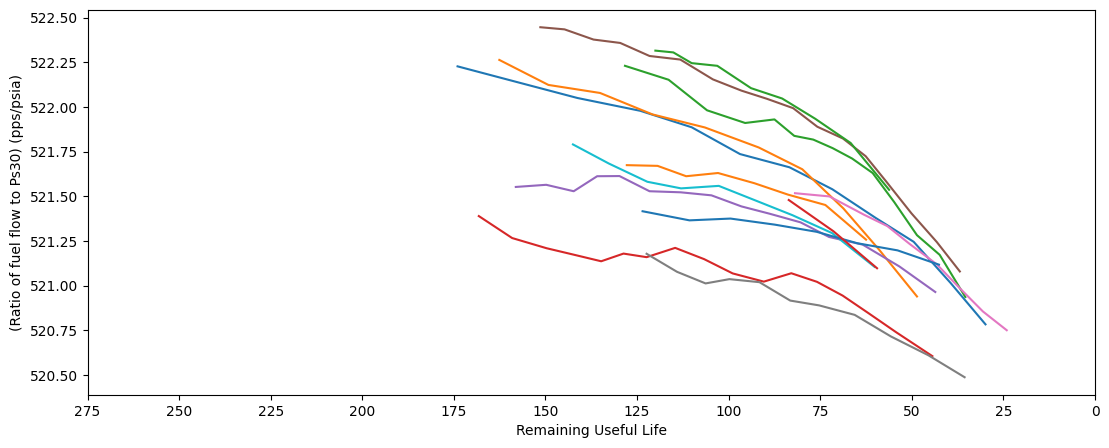

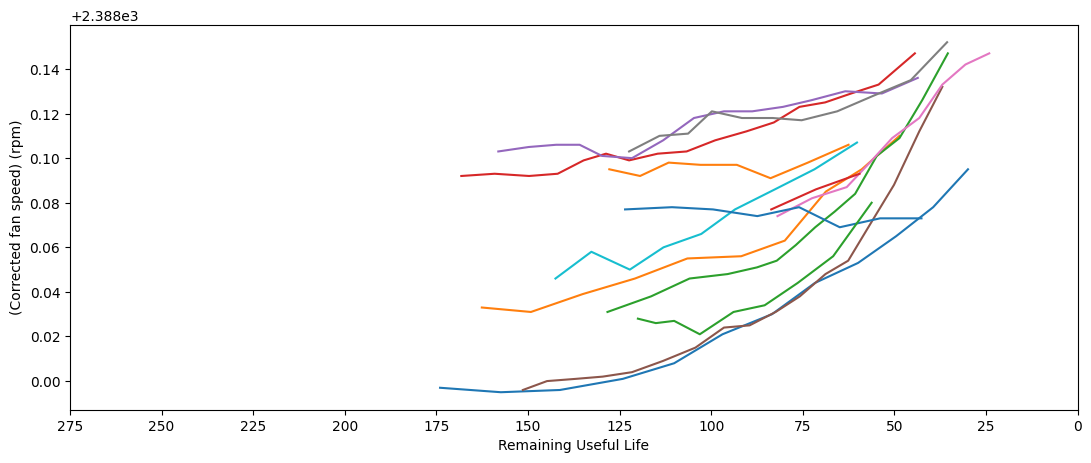

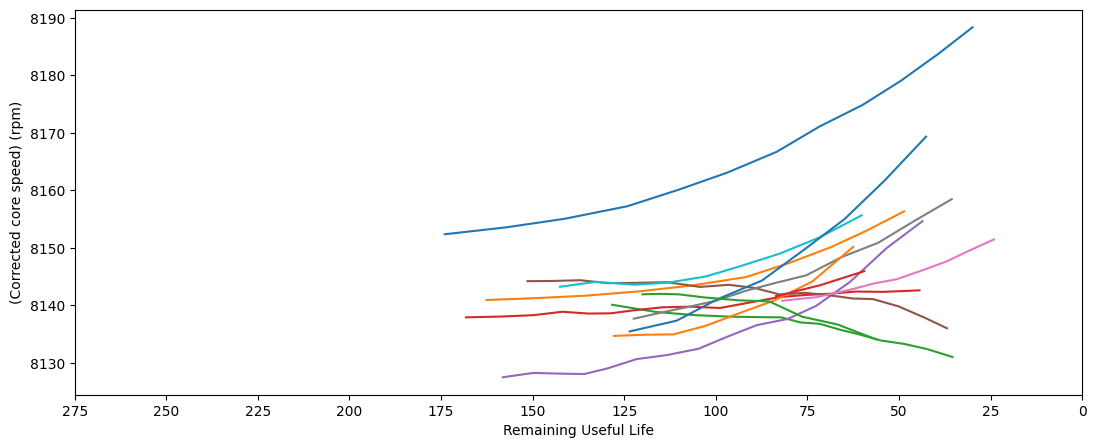

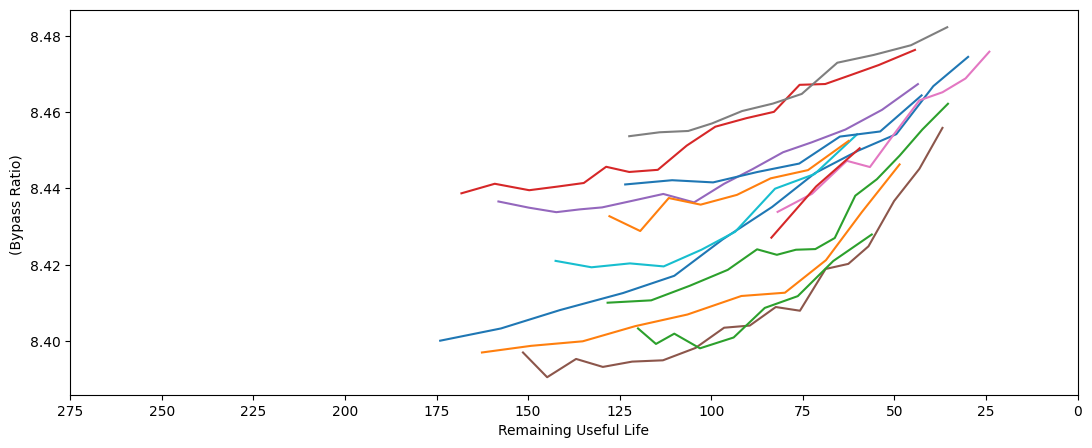

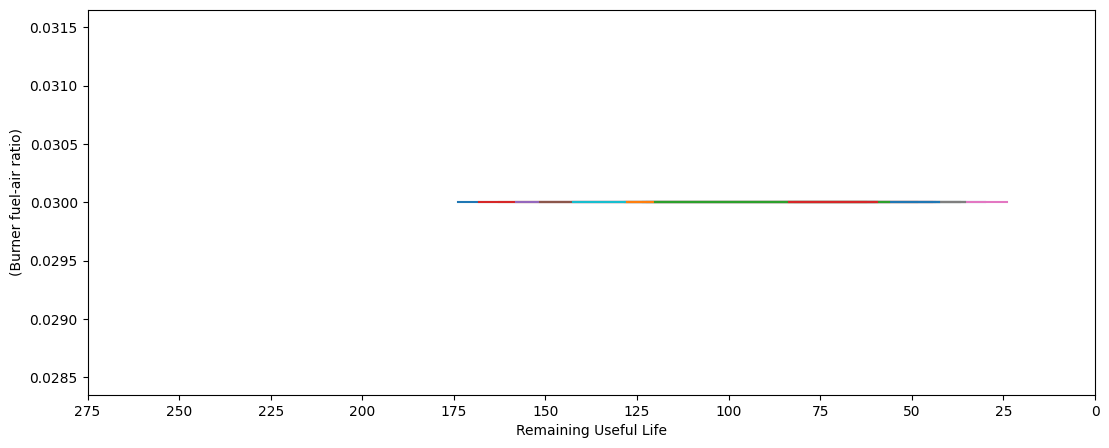

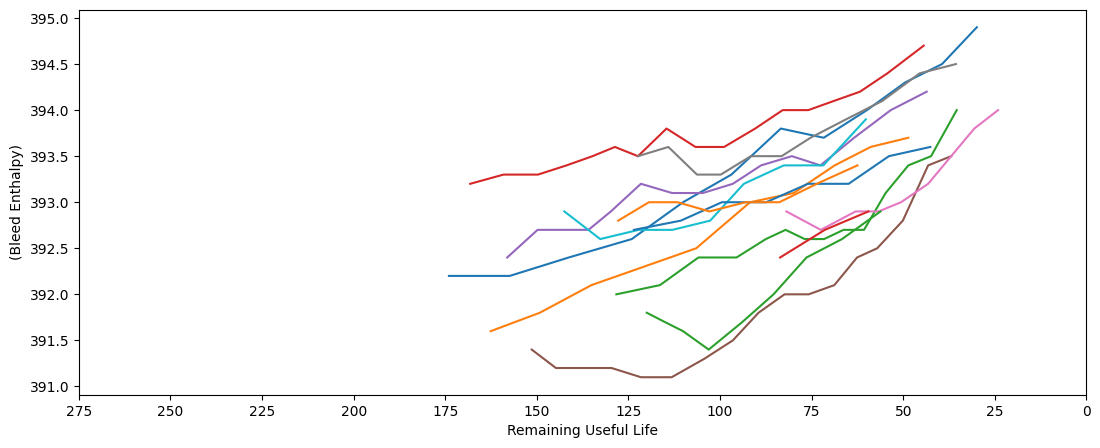

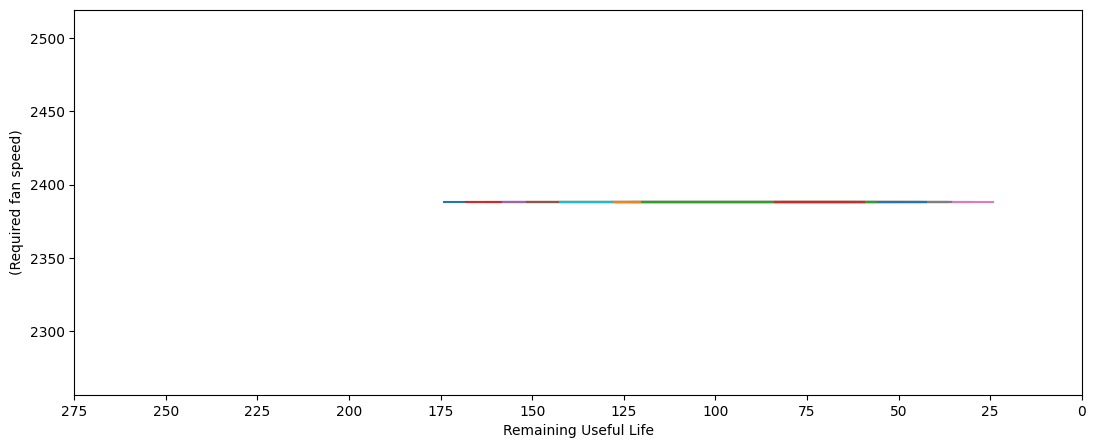

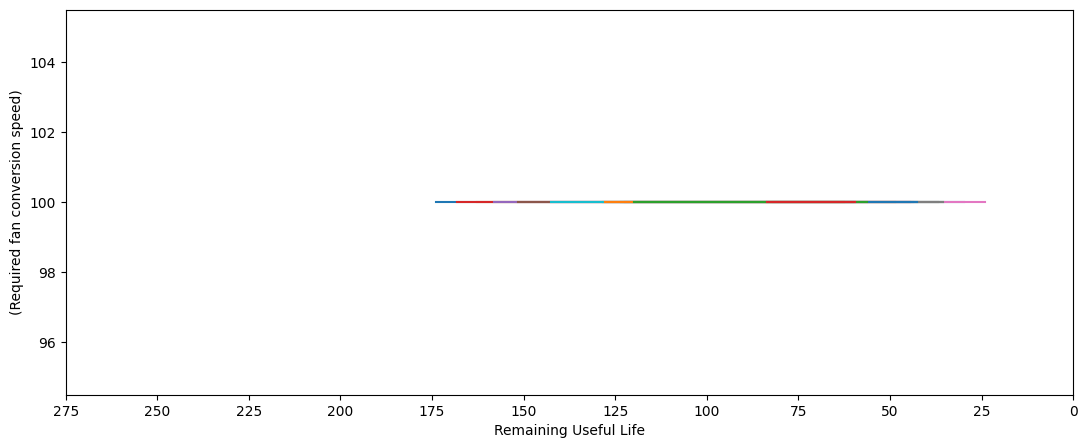

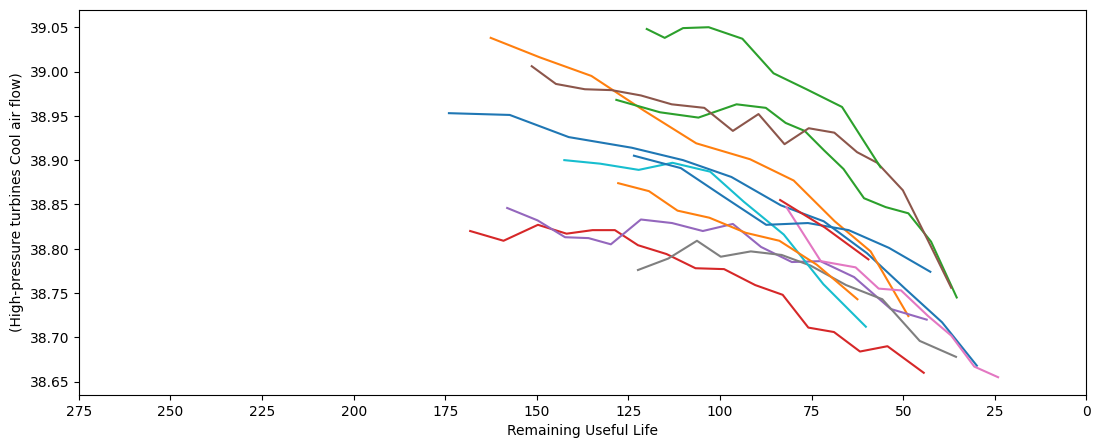

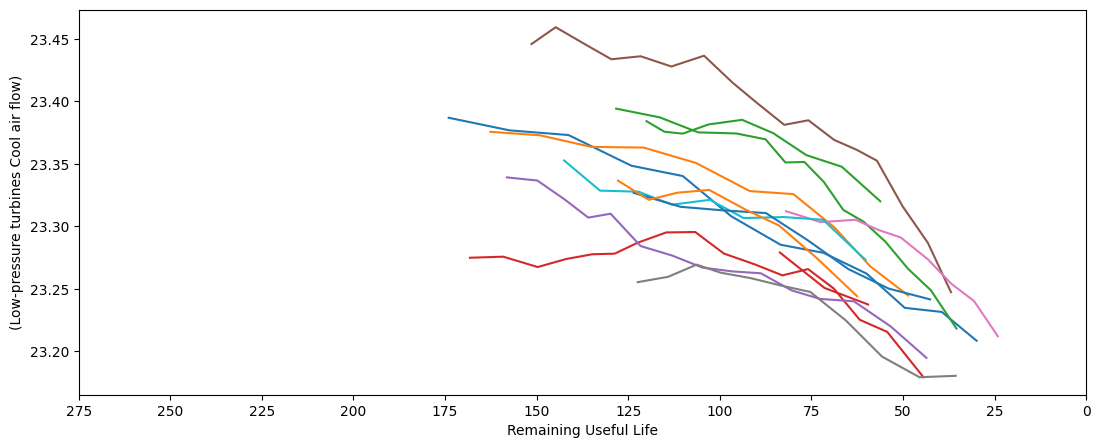

In [171]:
for i in range(1,22):
    try:
        plot_signal(train, Sensor_dictionary,'s_'+str(i))
    except:
        pass

MinMax scaler function : Transform features by scaling each feature to a given range.

This estimater scales and translates each feature individually such that it is in the given range on the training set

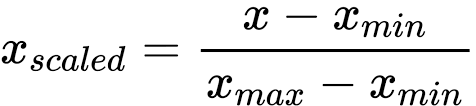

Dropping unnecessary features (labels and settings)

In [172]:
from sklearn.model_selection import train_test_split
drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()

Scaling the data

In [173]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

In [174]:
print(X_train)

          s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8  \
33     518.67  642.54  1581.47  1400.48  14.62  21.61  554.30  2388.03   
37     518.67  641.93  1589.60  1399.50  14.62  21.61  554.70  2388.08   
44     518.67  642.53  1582.42  1399.16  14.62  21.61  553.83  2388.08   
45     518.67  642.43  1588.29  1401.27  14.62  21.61  553.76  2388.06   
48     518.67  642.23  1584.35  1397.76  14.62  21.61  554.23  2388.07   
...       ...     ...      ...      ...    ...    ...     ...      ...   
13875  518.67  642.34  1584.83  1408.43  14.62  21.61  553.51  2388.11   
13894  518.67  642.98  1591.98  1414.06  14.62  21.61  553.76  2388.17   
13902  518.67  643.02  1592.28  1420.53  14.62  21.61  552.87  2388.18   
13938  518.67  643.09  1596.09  1424.03  14.62  21.61  552.74  2388.22   
13939  518.67  643.23  1593.02  1424.59  14.62  21.61  552.13  2388.17   

           s_9  s_10  ...    s_12     s_13     s_14    s_15  s_16  s_17  s_18  \
33     9046.46   1.3  ...  521

In [175]:
print(X_train_s)

[[0.         0.39051095 0.22458022 ... 0.         0.52       0.55863636]
 [0.         0.16788321 0.4141791  ... 0.         0.72       0.81257576]
 [0.         0.38686131 0.24673507 ... 0.         0.504      0.68757576]
 ...
 [0.         0.56569343 0.4766791  ... 0.         0.432      0.62075758]
 [0.         0.59124088 0.56553172 ... 0.         0.376      0.34545455]
 [0.         0.64233577 0.49393657 ... 0.         0.36       0.39106061]]


In [176]:
print(X_valid_s.shape)
print(y_valid.shape)
print(X_valid)
print(X_valid_s)

(650, 21)
(650, 1)
         s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8  \
8     518.67  642.10  1578.86  1402.60  14.62  21.61  553.17  2388.09   
12    518.67  642.48  1595.78  1406.83  14.62  21.61  554.27  2388.06   
14    518.67  642.50  1589.43  1402.10  14.62  21.61  553.57  2388.16   
15    518.67  642.27  1584.32  1405.75  14.62  21.61  554.60  2388.15   
34    518.67  642.90  1591.38  1409.90  14.62  21.61  554.01  2388.10   
...      ...     ...      ...      ...    ...    ...     ...      ...   
6464  518.67  642.90  1593.06  1425.39  14.62  21.61  552.14  2388.15   
6485  518.67  643.95  1600.81  1420.34  14.62  21.61  551.92  2388.19   
6490  518.67  643.12  1594.45  1426.04  14.62  21.61  551.06  2388.21   
6492  518.67  643.53  1601.23  1419.48  14.62  21.61  551.14  2388.17   
6500  518.67  643.85  1600.38  1432.14  14.62  21.61  550.79  2388.26   

          s_9  s_10  ...    s_12     s_13     s_14    s_15  s_16  s_17  s_18  \
8     9040.99   1.3  ...

In [177]:
print(y_valid)

      RUL
8     198
12    194
14    192
15    191
34    172
...   ...
6464   36
6485   15
6490   10
6492    8
6500    0

[650 rows x 1 columns]


Plotting features new distribution

# Model Implementation

Linear regression

Defining evaluation functions

In [178]:
# R2 score & RMSE & MSE
def evaluate(y_true, y_hat, label='test'):
    mse = mean_squared_error(y_true, y_hat)
    rmse = np.sqrt(mse)
    variance = r2_score(y_true, y_hat) # R2 score (R-squared) : indep. var.이 depend. var.을 얼마나 잘 설명하는가 (회귀모델 평가지표)
    print('{} set RMSE:{}, R2:{}'.format(label, rmse, variance))

In [179]:
# plot real data and the predicted one to make some comparison
def plot_predActual(y_test, y_test_hat):

    indices = np.arange(len(y_test_hat))
    wth= 0.6                                # width
    plt.figure(figsize=(70,30))
    true_values = [int(x) for x in y_test.values] # y : RUL
    predicted_values = list(y_test_hat)

    plt.bar(indices, true_values, width=wth,color='b', label='True RUL')
    plt.bar([i for i in indices], predicted_values, width=0.5*wth, color='r', alpha=0.7, label='Predicted RUL')

    plt.legend(prop={'size': 40})
    plt.tick_params(labelsize=40)

    plt.show()

**Use all feature**

In [180]:
print(X_train)

          s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8  \
33     518.67  642.54  1581.47  1400.48  14.62  21.61  554.30  2388.03   
37     518.67  641.93  1589.60  1399.50  14.62  21.61  554.70  2388.08   
44     518.67  642.53  1582.42  1399.16  14.62  21.61  553.83  2388.08   
45     518.67  642.43  1588.29  1401.27  14.62  21.61  553.76  2388.06   
48     518.67  642.23  1584.35  1397.76  14.62  21.61  554.23  2388.07   
...       ...     ...      ...      ...    ...    ...     ...      ...   
13875  518.67  642.34  1584.83  1408.43  14.62  21.61  553.51  2388.11   
13894  518.67  642.98  1591.98  1414.06  14.62  21.61  553.76  2388.17   
13902  518.67  643.02  1592.28  1420.53  14.62  21.61  552.87  2388.18   
13938  518.67  643.09  1596.09  1424.03  14.62  21.61  552.74  2388.22   
13939  518.67  643.23  1593.02  1424.59  14.62  21.61  552.13  2388.17   

           s_9  s_10  ...    s_12     s_13     s_14    s_15  s_16  s_17  s_18  \
33     9046.46   1.3  ...  521

In [181]:
X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1


**Linear regression**

In [182]:
print(X_train_1_s)
print(X_train_1_s.shape)
print(X_valid_1_s)
print(X_valid_1_s.shape)
print(X_full_1_s)
print(X_full_1_s.shape)

[[0.         0.39051095 0.22458022 ... 0.         0.52       0.55863636]
 [0.         0.16788321 0.4141791  ... 0.         0.72       0.81257576]
 [0.         0.38686131 0.24673507 ... 0.         0.504      0.68757576]
 ...
 [0.         0.56569343 0.4766791  ... 0.         0.432      0.62075758]
 [0.         0.59124088 0.56553172 ... 0.         0.376      0.34545455]
 [0.         0.64233577 0.49393657 ... 0.         0.36       0.39106061]]
(1398, 21)
[[0.         0.23655914 0.11540681 ... 0.         0.8125     0.73021879]
 [0.         0.37275986 0.60357761 ... 0.         0.625      0.52031584]
 [0.         0.37992832 0.4203693  ... 0.         0.67708333 0.50123376]
 ...
 [0.         0.60215054 0.56520485 ... 0.         0.16666667 0.17354828]
 [0.         0.74910394 0.76081939 ... 0.         0.3125     0.2010199 ]
 [0.         0.86379928 0.73629544 ... 0.         0.11458333 0.16022372]]
(650, 21)
[[0.         0.42394822 0.23827687 ... 0.         0.69158879 0.57129658]
 [0.         0.588

In [183]:
print(y_train_clip)
print(y_train_clip.shape)

33       155
37       151
44       144
45       143
48       140
        ... 
13875    117
13894     98
13902     90
13938     54
13939     53
Name: RUL, Length: 1398, dtype: int64
(1398,)


# **Loss function Tuning**

**1. Original MSE**

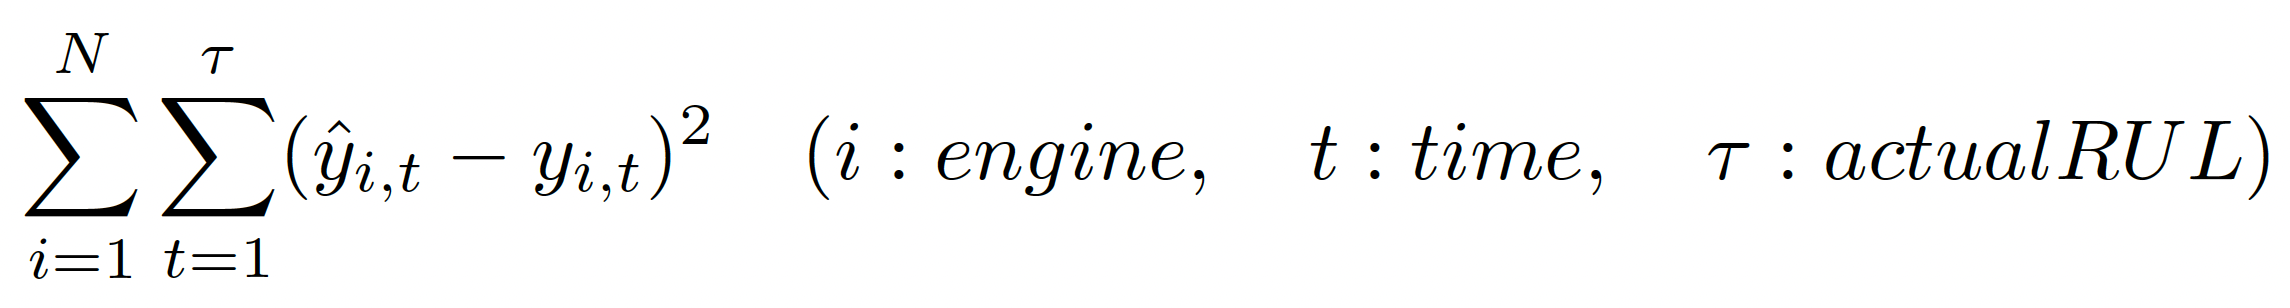

In [184]:

# 1. Original Linear Regression (모든 데이터 사용)
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')

print(lr1.coef_)

train set RMSE:39.04227070686199, R2:0.5788510204681064
valid set RMSE:48.497779541983135, R2:0.5178775332787678
full data set RMSE:45.39797829042482, R2:0.5603699665145848
[ 0.00000000e+00 -1.27448812e+01  4.26705944e+00 -2.65201629e+01
  3.55271368e-15 -1.36852880e+01  2.21782310e+01 -2.50484827e+01
 -8.64761975e+01 -1.95399252e-14 -5.01014806e+01  3.68808078e+01
 -1.71120923e+01 -4.17033928e+01 -2.56991223e+01  1.42108547e-14
 -2.05572896e+01 -4.01780296e-41  0.00000000e+00  1.74314638e+01
  1.36938053e+01]


**2. Crucial moments Loss function**

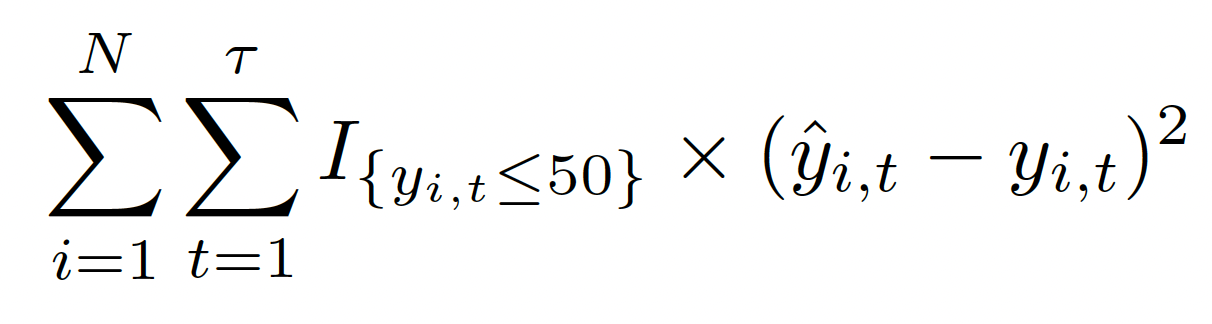

In [185]:
# 2. Crucial moments loss function - Linear Regression

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')

print(lr2.coef_)

train set RMSE:75.00025427538655, R2:-0.5541433967050422
valid set RMSE:86.72785972376394, R2:-0.541810212047485
full data set RMSE:84.12667628771229, R2:-0.5096691835297293
[ 0.00000000e+00 -4.64645006e+00 -7.13585993e+00 -8.76298506e-01
 -8.16013923e-15 -3.22307432e+00  1.46879152e+01 -1.42461241e+01
 -3.32341852e+01 -5.32907052e-15 -1.34744400e+01  9.13302838e+00
 -1.10405825e+01  1.94025953e+00  4.28472991e-01  0.00000000e+00
 -4.07625327e+00 -5.05095229e-40  1.46362822e-40 -4.56761158e-01
  1.01706349e+01]


**3. TD Style Loss function (ridge regression)**

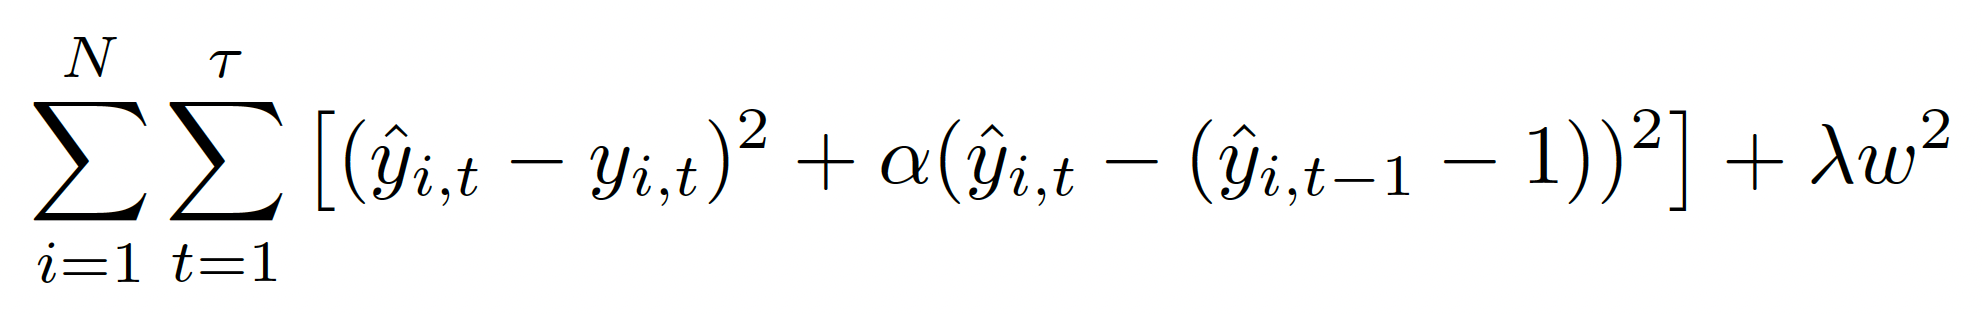

In [186]:
# Multi var linear regression

class Linear_Regression_TD() :
  def __init__( self, alpha=0, lambda_ridge=0 ) :
    self.alpha = alpha
    self.lambda_ridge = lambda_ridge  # Ridge regression

  def fit(self, X, Y, alpha, lambd) :
    self.l, self.p = X.shape
    self.alpha = alpha
    self.lambda_ridge = lambd
    # weight initializer
    self.p = (self.p + 1)         # add constant term.

    self.add_X = np.ones(self.l)
    self.X = np.c_[self.add_X, X]

    self.array_Y = np.array(Y[0:].to_numpy())
    self.array_Y.reshape( self.l, 1 )
    self.Y = self.array_Y
    self.W = np.zeros( self.p ) # W : 0 (b is included)

    self.identity = np.identity( n = self.p ) # Ridge regression
    self.lambda_identity = self.lambda_ridge * self.identity   # lambda * I

    # 각각의 행렬 연산
    X_T_X = (self.X.T) @ (self.X)          # X^(T)X
    X_diff_T_X_diff_sum = np.zeros( [self.p, self.p] )

    for i in range(1, self.l):
      X_diff_T_X_diff = (( self.X[i, :] - self.X[i - 1, :] ).reshape(self.p, 1)) @ (( self.X[i, :] - self.X[i - 1, :] ).reshape(1, self.p))
      X_diff_T_X_diff_sum += X_diff_T_X_diff


    X_T_Y = (self.X.T) @ (self.Y)
    X_T_Y = X_T_Y.reshape( self.p, 1 )
    X_diff_T_sum = np.zeros( [self.p, 1] )

    for i in range(1, self.l):
      X_diff_T = (( self.X[i, :] - self.X[i - 1, :] ).reshape( self.p, 1 ))
      X_diff_T_sum += X_diff_T

    self.W = np.linalg.inv(X_T_X + (self.alpha * X_diff_T_X_diff_sum) + self.lambda_identity) @ (X_T_Y - self.alpha * X_diff_T_sum)

    print(self.W)
    print(self.W.shape)

# X를 입력 받으면 첫 열에 1의 값을 갖는 열을 추가해서 계산해야함. (입력으로 들어오는 X는 (n, 21)이니 (n, 22)로 바꿔줘야 함)
  def predict( self, X) :
    l_X, p_X = X.shape
    p_X = p_X + 1
    add_col = np.ones(l_X)

    X = np.c_[add_col, X]

    return X.dot( self.W )

In [187]:
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


[[ 65.24682513]
 [  0.        ]
 [ -8.08058723]
 [  1.46823304]
 [-12.84850964]
 [  0.        ]
 [  3.33592619]
 [ 35.47615313]
 [ -5.06400164]
 [-34.71511848]
 [  0.        ]
 [-23.9436144 ]
 [ 39.43817507]
 [ -2.94613471]
 [-24.96551933]
 [-15.92862829]
 [  0.        ]
 [-14.08133379]
 [  0.        ]
 [  0.        ]
 [ 32.96615868]
 [ 26.04021238]]
(22, 1)
train set RMSE:41.042337891147184, R2:0.5345963350847216
valid set RMSE:50.40468123032927, R2:0.47921867172926047
full data set RMSE:48.20119048858614, R2:0.5044016434934528


**4. TD Style Loss function + Crucial moments (ridge regression)**

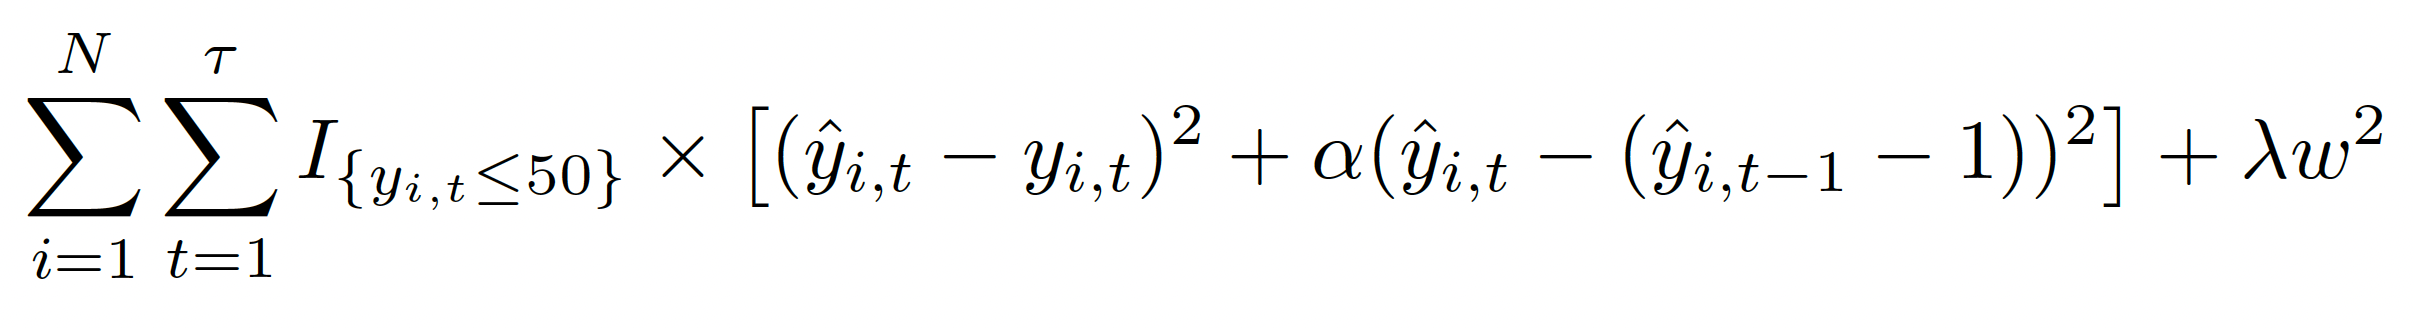

In [188]:
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')

[[10.05160237]
 [ 0.        ]
 [-1.2164195 ]
 [-1.77450242]
 [-2.37562123]
 [ 0.        ]
 [ 8.00452596]
 [10.67643011]
 [-1.08314557]
 [-5.39958892]
 [ 0.        ]
 [-4.05667084]
 [ 9.4535231 ]
 [-0.66811141]
 [-4.26277948]
 [-0.56099727]
 [ 0.        ]
 [-2.3529898 ]
 [ 0.        ]
 [ 0.        ]
 [ 7.32995622]
 [ 9.21464437]]
(22, 1)
train set RMSE:83.87085437777564, R2:-0.9435143435879656
valid set RMSE:95.21679585203476, R2:-0.8584067992483457
full data set RMSE:93.01215016156758, R2:-0.8454135122577005


5. Directed MSE

In [189]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models

In [190]:
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# Directed Mean Squared Error를 고려한 Loss function
def directed_mse_loss(y_true, y_pred):
    penalty = tf.where(y_pred > y_true, 13.0, 10.0)
    squared_error = tf.square(y_pred - y_true)
    return tf.reduce_mean(penalty * squared_error, axis=-1)

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

#predictions = lr5.predict(X_train_1_s).flatten()

In [191]:
y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data

65/65 [==============================] - 0s 757us/step


6. Directed Crucial moments MSE (20)

In [192]:
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data

65/65 [==============================] - 0s 747us/step


In [193]:
print(y_lr_train_6)
print(y_lr_full_6)

[[30.701712]
 [37.571503]
 [30.807669]
 ...
 [24.11039 ]
 [20.307646]
 [18.199537]]
[[34.393173]
 [30.873014]
 [31.499723]
 ...
 [15.495074]
 [14.769572]
 [10.388561]]


Merge!

In [194]:
y_lr_valid_1

array([137.25813247, 136.45433875, 122.91785362, 136.32422694,
       132.43533341, 121.74074228, 116.22457655, 104.89652278,
       122.93647075,  97.63047195, 111.70595669, 111.86842817,
        94.03725631, 114.9925493 ,  84.77592192,  72.72193155,
        83.62368111,  87.08664239,  82.56092615,  57.2597398 ,
        40.12684528, -47.65486768, -66.41331689, 137.26150036,
       143.81886328, 138.87933079, 148.9081421 , 134.40563899,
       153.32988535, 142.42762042, 140.73170041, 141.43767863,
       137.09989419, 128.70880788, 129.57768898, 118.03646086,
        98.29944045,  57.93838123, 121.84484321, 108.40639953,
       108.15573994, 112.198503  , 108.92914741, 104.40101603,
       110.51319296, 101.62966229,  99.59002375, 109.62410195,
        95.32351343,  90.41314282,  98.6383596 ,  92.31658272,
        84.66162408,  95.90147624,  98.98774476,  84.71789897,
        99.28197425,  80.13215463,  83.78801026,  91.08666685,
        69.45180548,  60.78114204,  48.75538145,   4.38

concat을 위해 index 제거. 제거하지 않으면 NaN 값들이 데이터프레임에 들어감.

In [195]:
X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

In [196]:
# loss function 별 dataframe들을 list로 저장
y_lr_valid_dfs = [pd.DataFrame(y_lr_valid_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_6, columns=['predicted RUL'])]
merged_valid_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_valid_df in enumerate(y_lr_valid_dfs, start=1):
    merged_valid = pd.concat([X_valid_index_names, y_lr_valid_df, y_valid], axis=1)
    merged_valid_dfs.append(merged_valid)
    print(f"Merged Valid DataFrame {i}:\n", merged_valid)

Merged Valid DataFrame 1:
      unit_number  time_cycles  predicted RUL  RUL
0             71            9     137.258132  198
1             71           13     136.454339  194
2             71           15     122.917854  192
3             71           16     136.324227  191
4             71           35     132.435333  172
..           ...          ...            ...  ...
645          100          164      48.228146   36
646          100          185      39.274287   15
647          100          190       2.362600   10
648          100          192      16.815338    8
649          100          200     -17.162770    0

[650 rows x 4 columns]
Merged Valid DataFrame 2:
      unit_number  time_cycles  predicted RUL  RUL
0             71            9      51.339709  198
1             71           13      47.373476  194
2             71           15      41.261227  192
3             71           16      49.929907  191
4             71           35      46.213237  172
..           ...      

In [197]:
# loss function 별 dataframe들을 list로 저장
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

Merged full DataFrame 1:
       unit_number  time_cycles  predicted RUL  RUL
0               1            8     158.479909  176
1               1           13     126.047582  171
2               1           17     135.916772  167
3               1           19     139.731861  165
4               1           33     145.887767  151
...           ...          ...            ...  ...
2058          100          136      89.706982   60
2059          100          148      80.527969   48
2060          100          165      43.292330   31
2061          100          192      20.803487    4
2062          100          196       2.498161    0

[2063 rows x 4 columns]
Merged full DataFrame 2:
       unit_number  time_cycles  predicted RUL  RUL
0               1            8      57.426473  176
1               1           13      45.141880  171
2               1           17      52.160579  167
3               1           19      52.819580  165
4               1           33      53.025020  151
...  

# Visualization

**(1) 각 엔진의 online predict value (test data 71~100)**

(X-axis : Time cycles, Y-axis : predicted RUL)

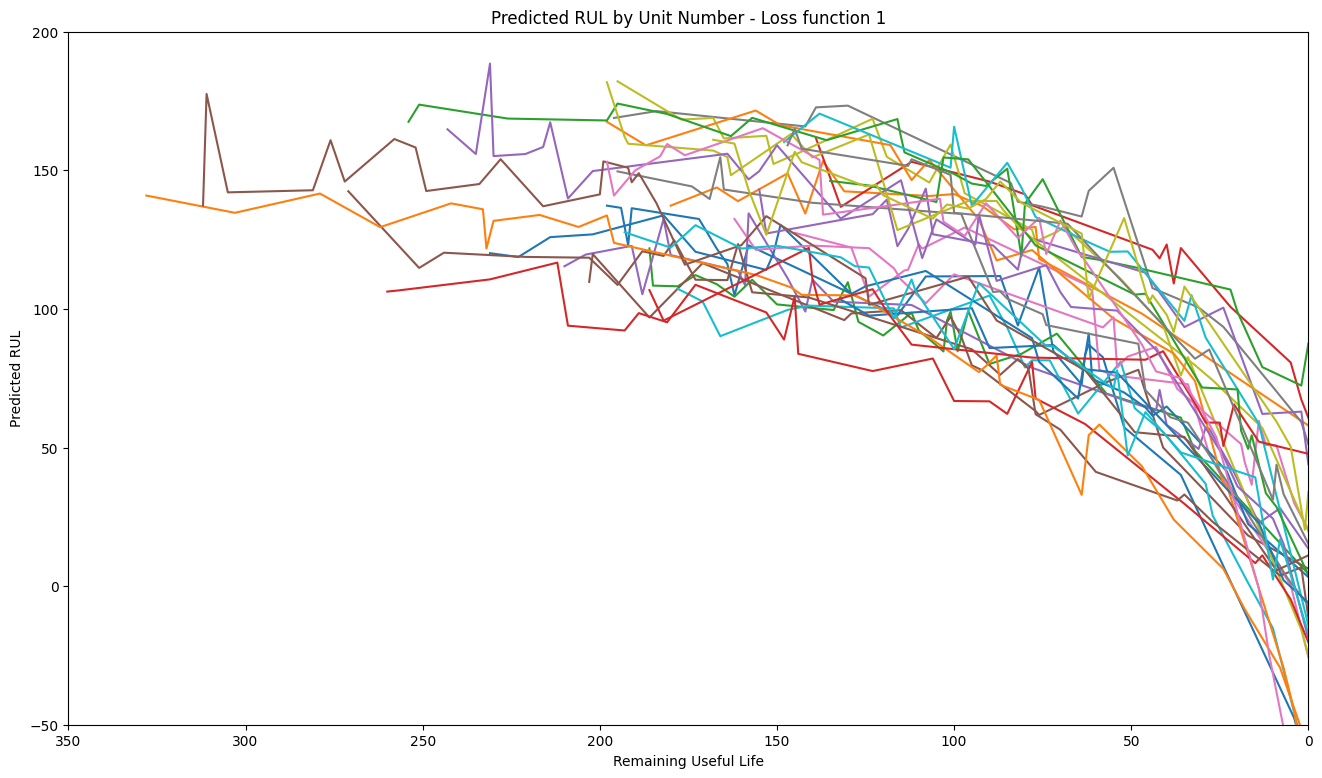

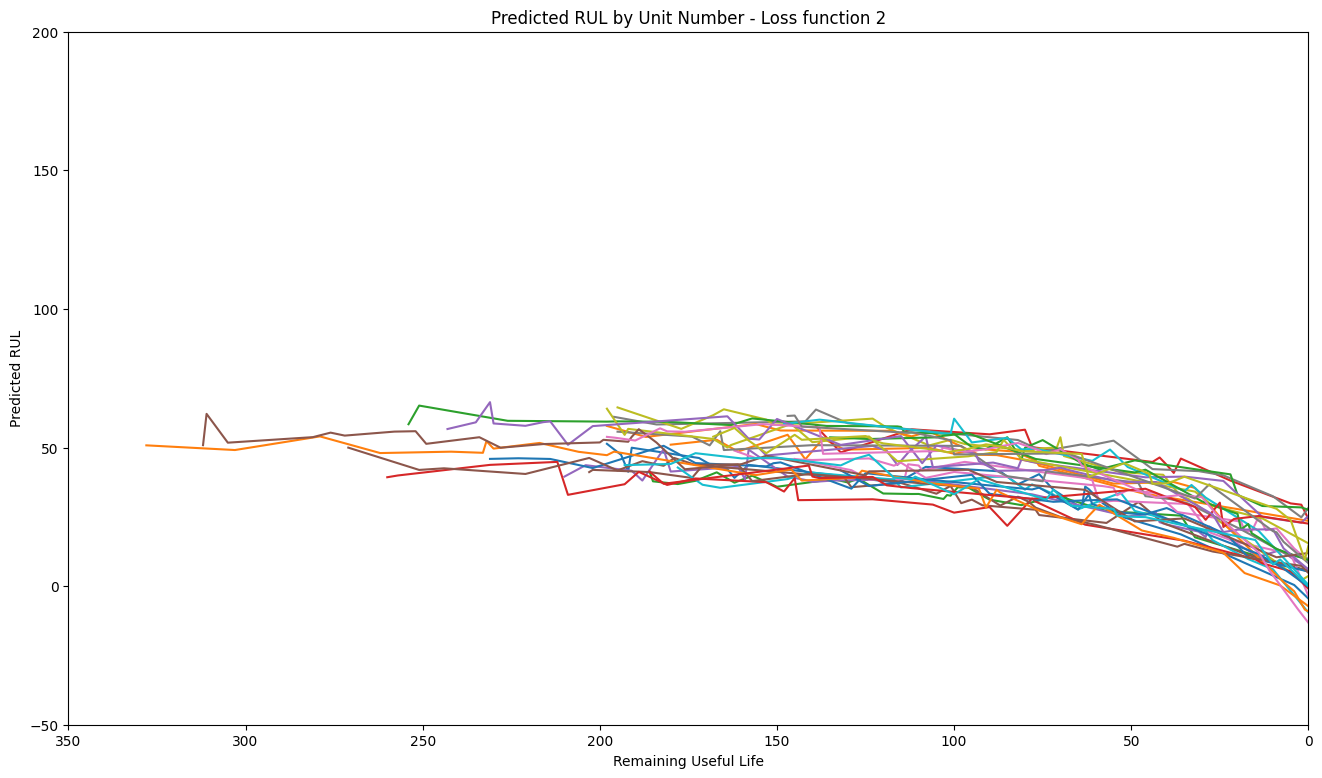

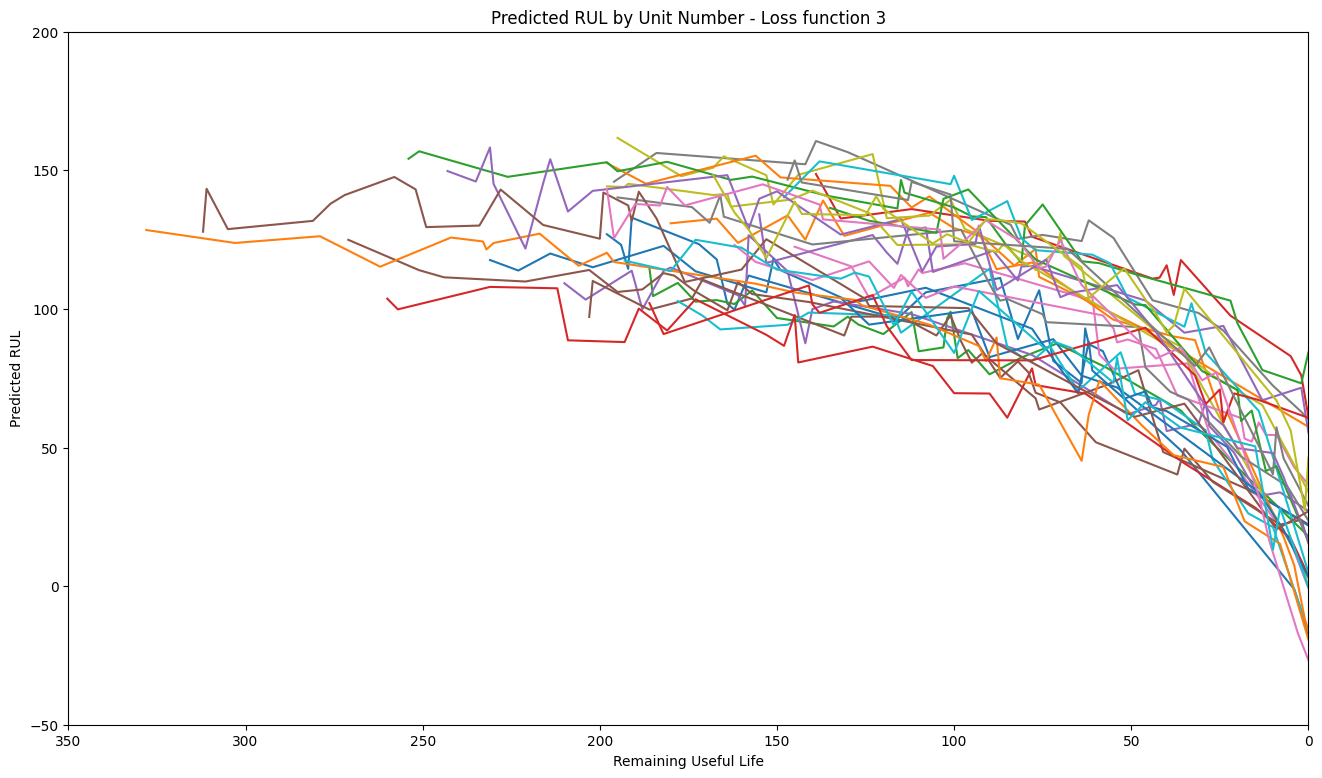

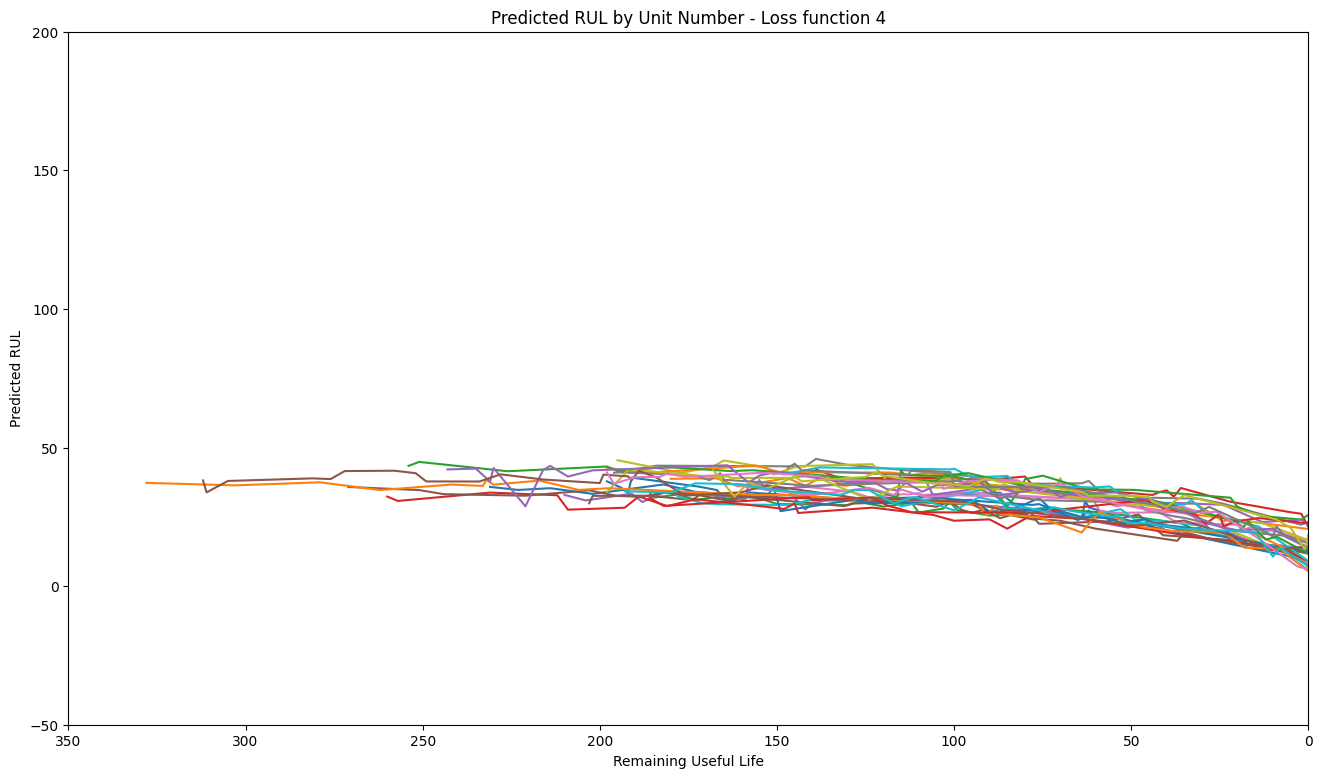

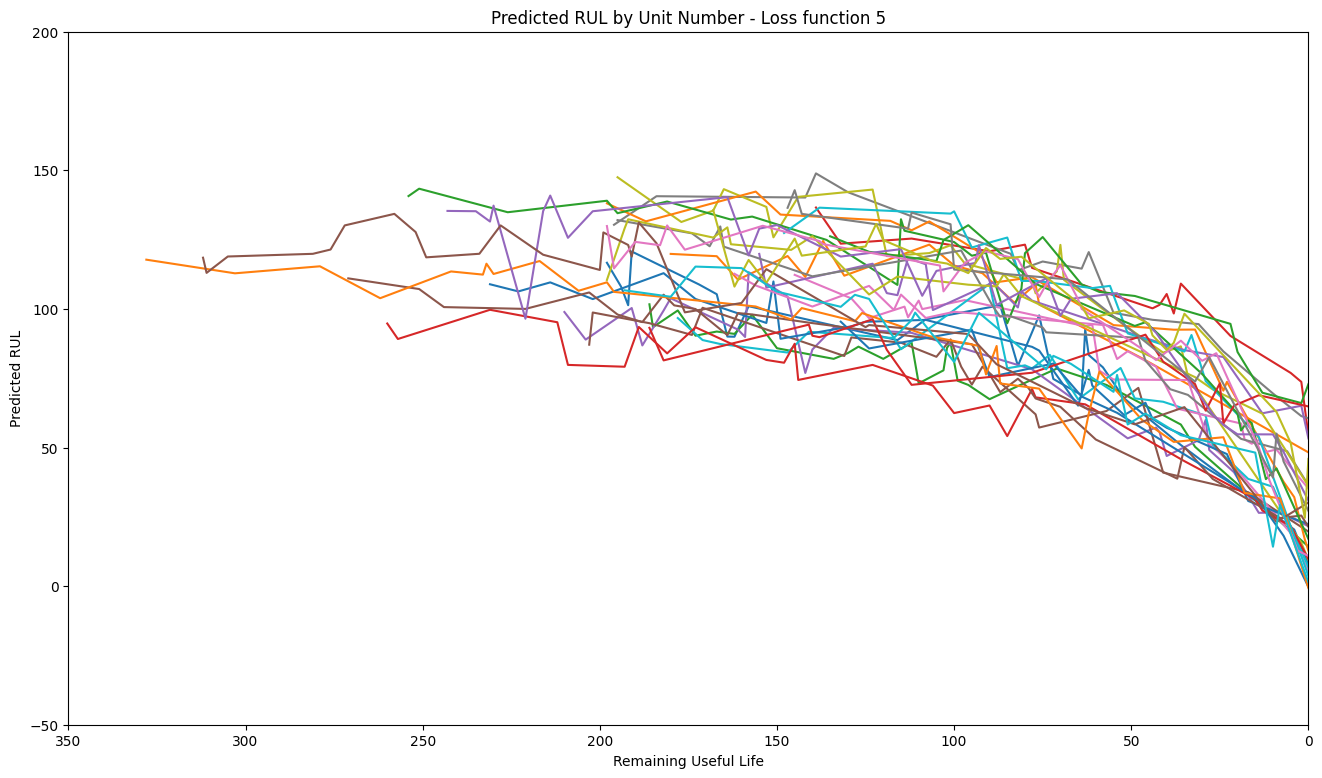

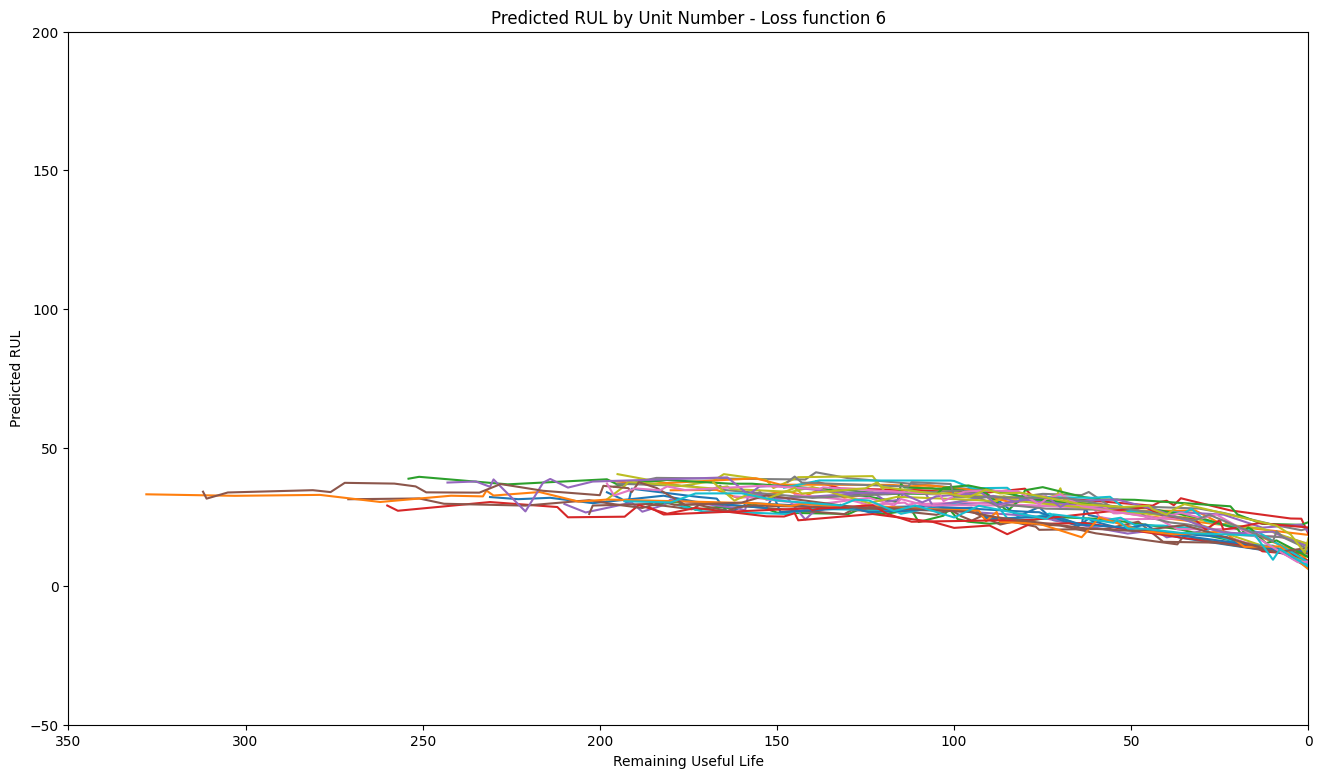

In [198]:
# merged_valid_dfs 리스트에 있는 데이터프레임들에 대해 반복 수행
for i, merged_valid_df in enumerate(merged_valid_dfs, start=1):
    # 데이터프레임에서 unit_number을 기준으로 그룹화
    grouped = merged_valid_df.groupby('unit_number')

    # 그래프를 그릴 subplot을 설정
    fig, ax = plt.subplots(figsize=(16, 9))

    # unit_number 별로 그래프 그리기
    for unit, group in grouped:
        ax.plot(group['RUL'], group['predicted RUL'], label=f'Unit {unit}')

    ax.set_xlabel('Remaining Useful Life')
    ax.set_ylabel('Predicted RUL')
    ax.set_title(f'Predicted RUL by Unit Number - Loss function {i}')
    #ax.legend(loc='upper right')  # 범례 추가

    # 그래프 출력 설정
    plt.xlim(350, 0)  # reverse the x-axis so RUL counts down to zero
    plt.ylim(-50, 200)
    plt.show()

**Threshold, Actual Operation Time**

**Add "Cumulative Operation Time", "Total Cost" Columns**


Cost : Failure (10,000), replace (1000)

**Apply full data set**

In [199]:
# define list of threshold_value
threshold_start = -40        # -40
threshold_end = 90           # 90
threshold_values = list(range(threshold_start, threshold_end + 1))

# Define cost (Tentative Value)
REPLACE_COST = 1000       # replace cost를 크게 늘려도, 반등하는 최저점을 찾을 수 없음 <- Total cost로 해서 상수가 나왔었음. 시간당 cost로 환산하면 커브 그려짐.
FAILURE_COST = 10000

In [200]:
# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()
            """
            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break
            """

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])

**(2) Threshold를 x축으로 두고 분석**

(x-axis : Threshold, y-axis : Number of replace failures)


(x-axis : Threshold, y-axis : Total Cost)

**apply full data**

In [201]:
# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)

DataFrame for merged_valid_df 1:
      Threshold  Number of replace failures  Total Cost  Average usage time
0          -40                          89   48.104645              187.30
1          -39                          88   47.624132              187.30
2          -38                          87   47.156208              187.25
3          -37                          86   46.675567              187.25
4          -36                          86   46.675567              187.25
..         ...                         ...         ...                 ...
126         86                           0    6.961849              143.64
127         87                           0    7.085666              141.13
128         88                           0    7.215528              138.59
129         89                           0    7.311545              136.77
130         90                           0    7.374631              135.60

[131 rows x 4 columns]
DataFrame for merged_valid_df 2:
      Thr

In [202]:
full_nan_counts_and_cost_df_lists = []
full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

**여기부터 average usage time 적용!**

**Scatter plot - Threshold에 따른 replace 실패 횟수와, 엔진 평균 사용시간 - Full data**

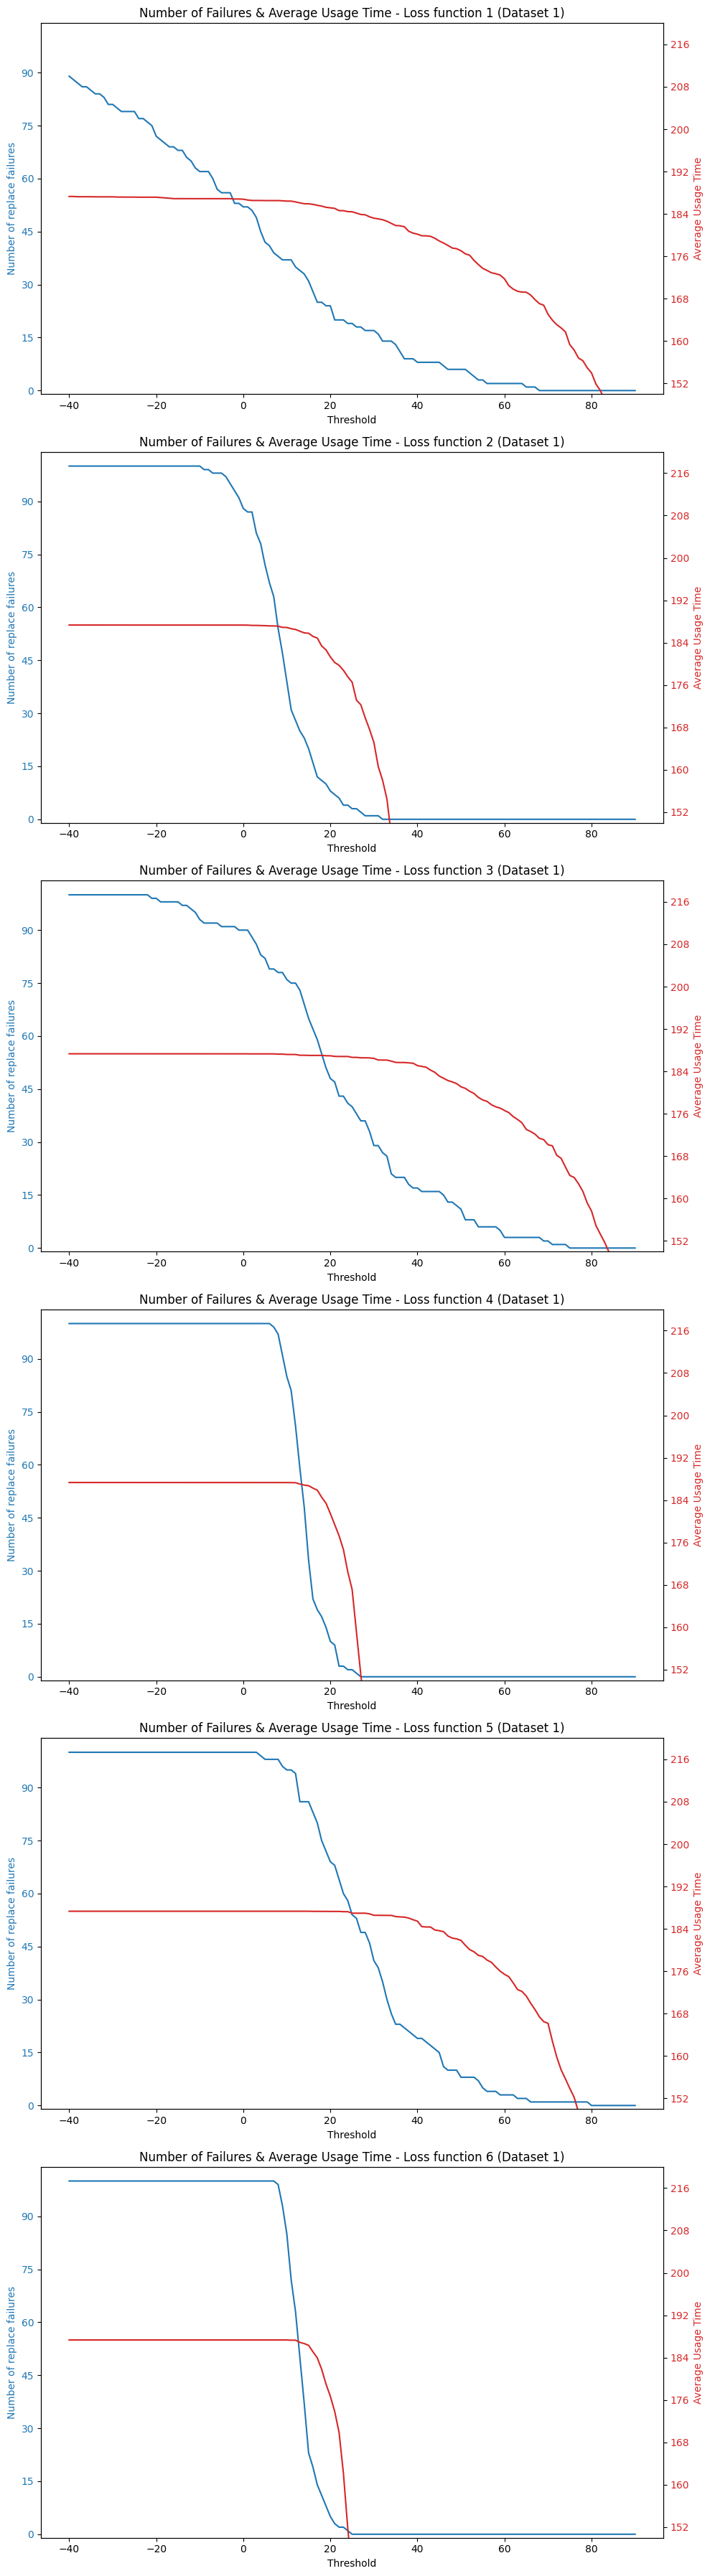

In [203]:
fig, axs = plt.subplots(len(full_nan_counts_and_cost_df_list), 1, figsize=(10, 6*len(full_nan_counts_and_cost_df_list)))

# 데이터프레임들을 저장한 리스트인 nan_counts_and_cost_df_list 내의 각 데이터프레임에 대해 반복 수행
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list, start=1):
    ax1 = axs[i-1]

    # 왼쪽 Y축 그래프 (Number of failures)
    color = 'tab:blue'
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Number of replace failures', color=color)
    ax1.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Number of replace failures'], color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax1.set_ylim(-1,104) ### for Dataset1
    #ax1.set_ylim(-5,270) ### for Dataset2
    #ax1.set_ylim(-1,104) ### for Dataset3
    #ax1.set_ylim(-5,260) ### for Dataset4

    # 오른쪽 Y축 그래프 (Average Usage Time)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Average Usage Time', color=color)
    ax2.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Average usage time'], color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax2.set_ylim(150,220) ### for Dataset1
    #ax2.set_ylim(135,220) ### for Dataset2
    #ax2.set_ylim(190,260) ### for Dataset3
    #ax2.set_ylim(180,260) ### for Dataset4

    # 그래프 제목 설정
    ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 1)')
    #ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 2)')
    #ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 3)')
    #ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 4)')

# 그래프 보이기
plt.tight_layout()  # subplot 간격 조정
plt.show()

Average Cost

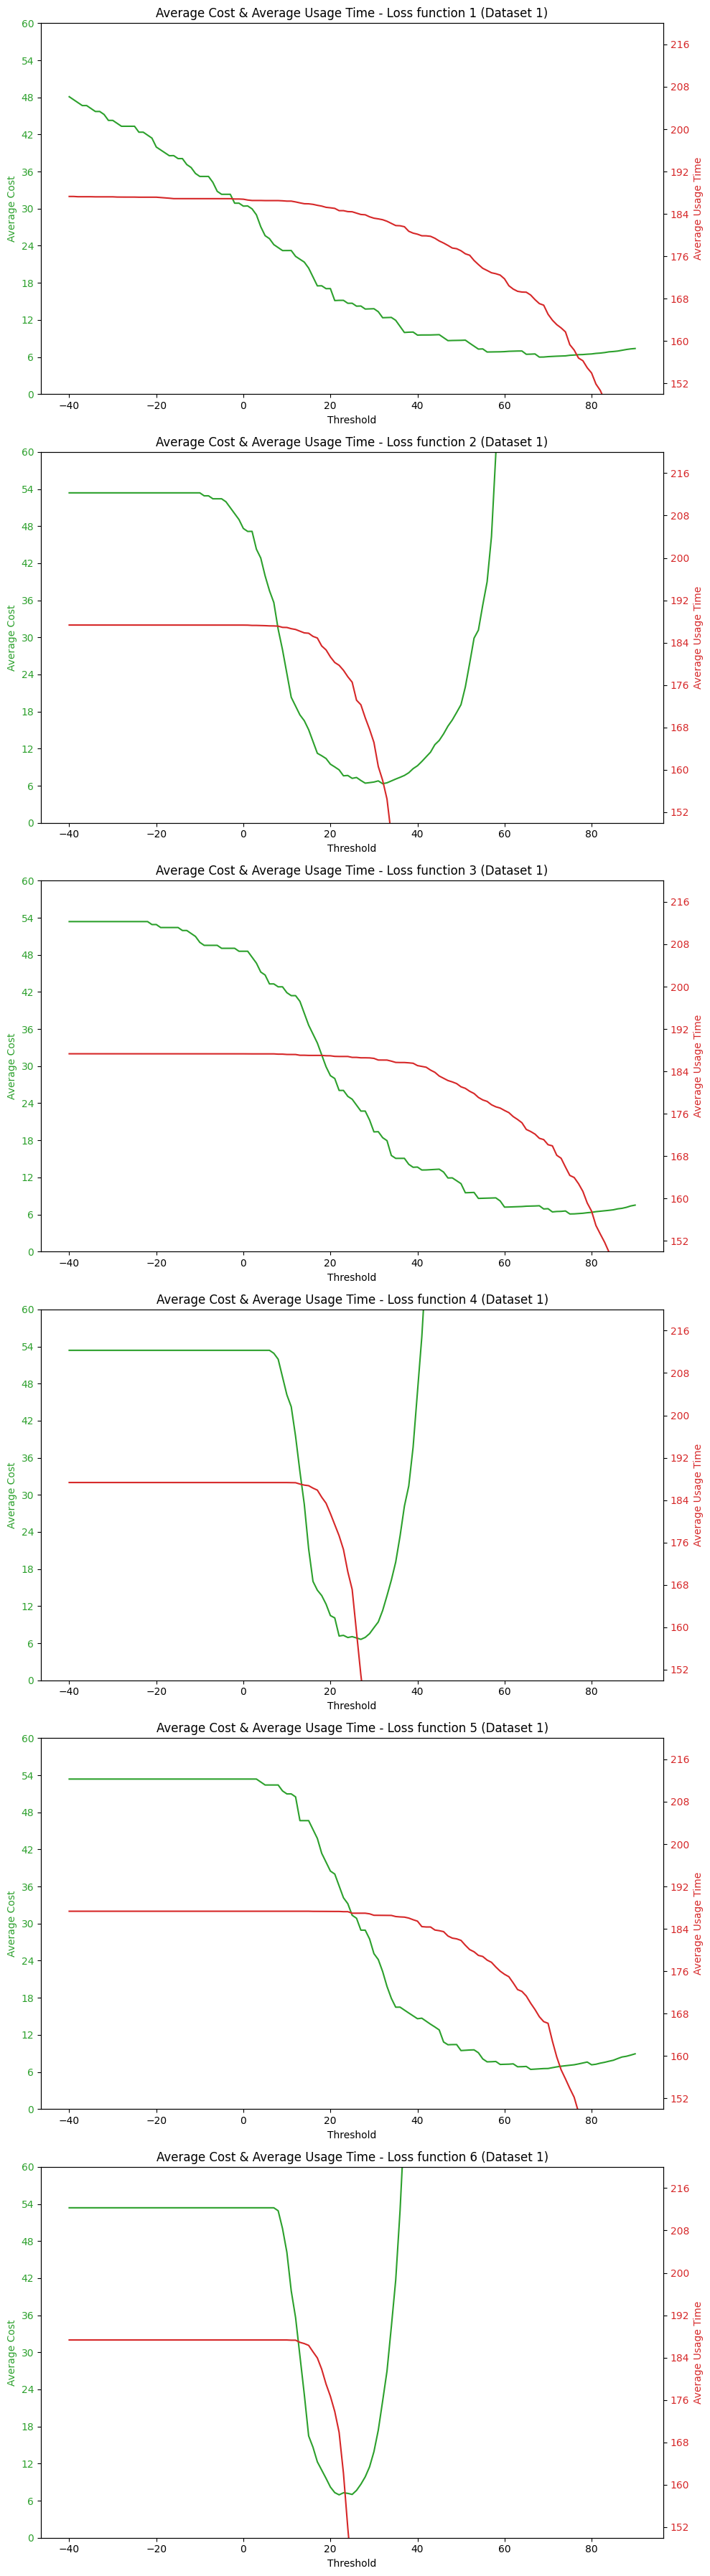

In [204]:
fig, axs = plt.subplots(len(full_nan_counts_and_cost_df_list), 1, figsize=(10, 6*len(full_nan_counts_and_cost_df_list)))

# 데이터프레임들을 저장한 리스트인 nan_counts_and_cost_df_list 내의 각 데이터프레임에 대해 반복 수행
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list, start=1):
    ax1 = axs[i-1]

    # 왼쪽 Y축 그래프 (Average Cost)
    color = 'tab:green'
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Average Cost', color=color)
    ax1.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Total Cost'], color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax1.set_ylim(0,60) ### for dataset1
    #ax1.set_ylim(0,60) ### for dataset2
    #ax1.set_ylim(0,60) ### for dataset3
    #ax1.set_ylim(0,60) ### for dataset4
    """
    # 오른쪽 Y축 그래프 (Total Number of Engines Used)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Total Number of Engines Used', color=color)
    ax2.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Last index'] + 1, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax2.set_ylim(75,100)
    """
    # 오른쪽 Y축 그래프 (Average Usage Time)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Average Usage Time', color=color)
    ax2.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Average usage time'], color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax2.set_ylim(150,220) ### for Dataset1
    #ax2.set_ylim(0,220) ### for Dataset2
    #ax2.set_ylim(190,260) ### for Dataset3
    #ax2.set_ylim(-0.5,260) ### for Dataset4

    # 그래프 제목 설정
    ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 1)')
    #ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 2)')
    #ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 3)')
    #ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 4)')

# 그래프 보이기
plt.tight_layout()  # subplot 간격 조정
plt.show()

**Scatter Plot - (Number of Failures vs. Average usage time)**

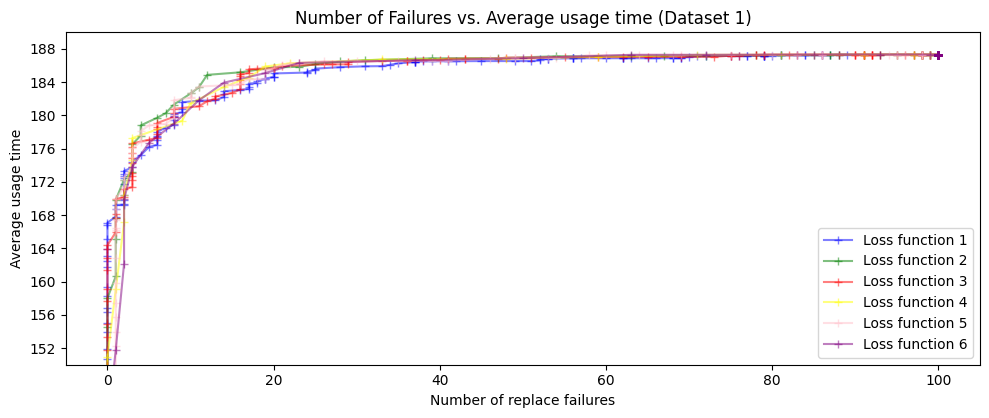

In [205]:
# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(10, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list):

    ax.plot(
        full_nan_counts_and_cost_df['Number of replace failures'],
        full_nan_counts_and_cost_df['Average usage time'],
        '+-',
        label=f'Loss function {i + 1}',
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 2)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 3)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 4)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(150,190) ### for dataset1
#ax.set_ylim(135,220) ### for dataset2
#ax.set_ylim(190,248) ### for dataset3
#ax.set_ylim(180,260) ### for dataset4

ax.set_xlim(-5,105) ### for dataset1,3
#ax.set_xlim(-5,265) ### for dataset2
#ax.set_xlim(-5,255) ### for dataset4

# Set aspect ratio to make the plot square
ax.set_aspect('equal')

# Show the plot
plt.tight_layout()
plt.show()

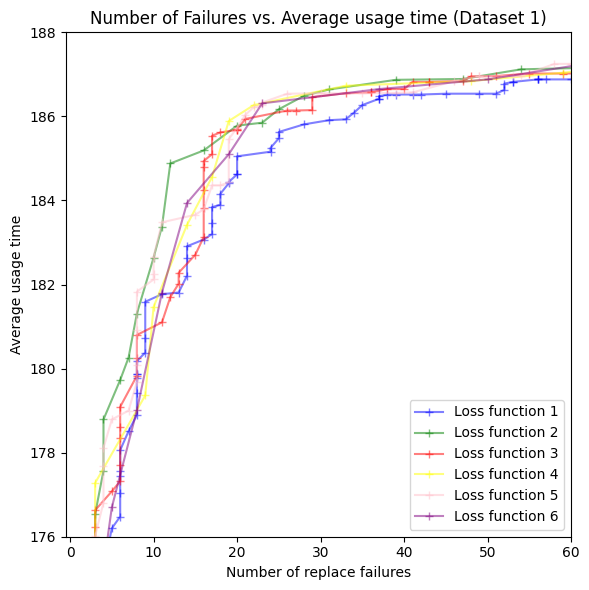

In [206]:
# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list):
    ax.plot(
        full_nan_counts_and_cost_df['Number of replace failures'],
        full_nan_counts_and_cost_df['Average usage time'], '+-',
        label=f'Loss function {i + 1}',
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 2)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 3)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 4)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(176,188) ### for dataset1
#ax.set_ylim(172,205) ### for dataset2
#ax.set_ylim(226,240) ### for dataset3
#ax.set_ylim(190,237) ### for dataset4
ax.set_xlim(-0.5,60)

# Set aspect ratio to make the plot square
#ax.set_aspect('equal')

# Show the plot
plt.tight_layout()
plt.show()

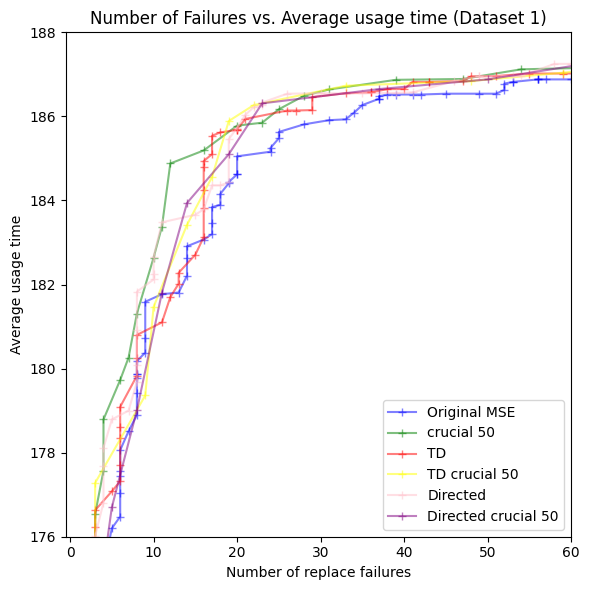

In [207]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list):
    ax.plot(
        full_nan_counts_and_cost_df['Number of replace failures'],
        full_nan_counts_and_cost_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(176,188) ### for dataset1

ax.set_xlim(-0.5,60)


# Show the plot
plt.tight_layout()
plt.show()

# 반복 시작 (나중에 최적화)

2번 샘플에 대해 코드 실행 (계속 반복)

In [208]:
train = sampled_data_list[1][0].copy()
valid = sampled_data_list[1][1].copy()
full_data = sampled_data_list[1][2].copy()

In [209]:
train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

In [210]:
drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

In [211]:
X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

In [212]:
# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


train set RMSE:37.44539095614108, R2:0.6198554913343649
valid set RMSE:49.879716601368656, R2:0.5249819944322707
full data set RMSE:45.91028184683836, R2:0.567720349818068
train set RMSE:76.20238572206985, R2:-0.5743058866959021
valid set RMSE:93.48489361624802, R2:-0.668572161663523
full data set RMSE:88.98139386570153, R2:-0.6238401772463695
[[ 56.11548663]
 [  0.        ]
 [-15.37169269]
 [-12.92685238]
 [-15.26272654]
 [  0.        ]
 [  5.40234847]
 [ 41.48496963]
 [  1.63678578]
 [-25.17053552]
 [  0.        ]
 [-28.58004452]
 [ 41.1997178 ]
 [ -0.94604956]
 [-24.28766959]
 [ -5.34789579]
 [  0.        ]
 [-12.43254071]
 [  0.        ]
 [  0.        ]
 [ 25.25558024]
 [ 31.88821894]]
(22, 1)
train set RMSE:39.33881106153417, R2:0.5804396462522069
valid set RMSE:52.17488214898096, R2:0.4802612820621127
full data set RMSE:48.8389148847389, R2:0.510810771506985
[[ 9.70405031]
 [ 0.        ]
 [ 0.41180404]
 [-3.71933597]
 [-3.21290494]
 [ 0.        ]
 [ 9.70405031]
 [10.27686487]
 [-

In [213]:
X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])

Merged full DataFrame 1:
       unit_number  time_cycles  predicted RUL  RUL
0               1            5     134.412176  179
1               1            7     139.206077  177
2               1            8     142.054331  176
3               1           14     132.284468  170
4               1           20     144.642155  164
...           ...          ...            ...  ...
2058          100          163      35.711450   27
2059          100          171      34.036193   19
2060          100          172      31.642457   18
2061          100          182      16.690097    8
2062          100          190       2.558030    0

[2063 rows x 4 columns]
Merged full DataFrame 2:
       unit_number  time_cycles  predicted RUL  RUL
0               1            5      48.097835  179
1               1            7      47.695937  177
2               1            8      52.165187  176
3               1           14      43.731373  170
4               1           20      54.324089  164
...  

In [214]:
# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)

DataFrame for merged_valid_df 1:
      Threshold  Number of replace failures  Total Cost  Average usage time
0          -40                          90   48.691744              186.89
1          -39                          89   48.210177              186.89
2          -38                          89   48.210177              186.89
3          -37                          89   48.210177              186.89
4          -36                          87   47.247044              186.89
..         ...                         ...         ...                 ...
126         86                           1    8.373665              130.17
127         87                           1    8.428052              129.33
128         88                           1    8.530286              127.78
129         89                           1    8.615239              126.52
130         90                           1    8.748696              124.59

[131 rows x 4 columns]
DataFrame for merged_valid_df 2:
      Thr

In [215]:
full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

테스트용 코드, 2번째 샘플에 대한 결과.

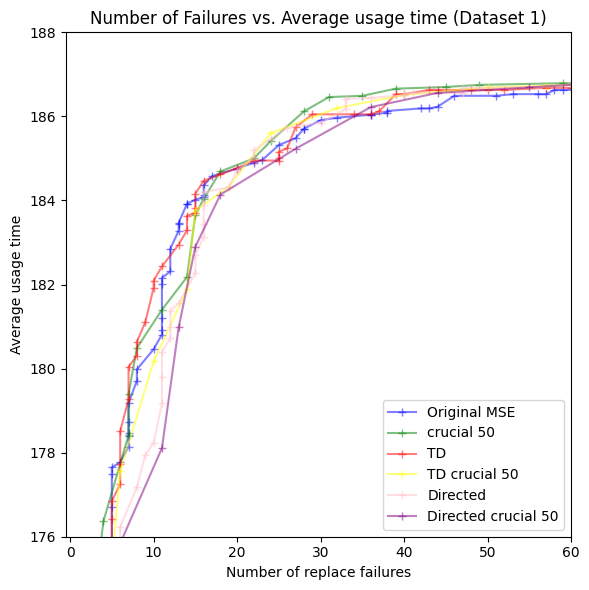

In [216]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list):
    ax.plot(
        full_nan_counts_and_cost_df['Number of replace failures'],
        full_nan_counts_and_cost_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(176,188) ### for dataset1

ax.set_xlim(-0.5,60)


# Show the plot
plt.tight_layout()
plt.show()

In [217]:
full_nan_counts_and_cost_df_lists

[[     Threshold  Number of replace failures  Total Cost  Average usage time
  0          -40                          89   48.104645              187.30
  1          -39                          88   47.624132              187.30
  2          -38                          87   47.156208              187.25
  3          -37                          86   46.675567              187.25
  4          -36                          86   46.675567              187.25
  ..         ...                         ...         ...                 ...
  126         86                           0    6.961849              143.64
  127         87                           0    7.085666              141.13
  128         88                           0    7.215528              138.59
  129         89                           0    7.311545              136.77
  130         90                           0    7.374631              135.60
  
  [131 rows x 4 columns],
       Threshold  Number of replace failures  T

In [218]:
full_nan_counts_and_cost_df_list

[     Threshold  Number of replace failures  Total Cost  Average usage time
 0          -40                          90   48.691744              186.89
 1          -39                          89   48.210177              186.89
 2          -38                          89   48.210177              186.89
 3          -37                          89   48.210177              186.89
 4          -36                          87   47.247044              186.89
 ..         ...                         ...         ...                 ...
 126         86                           1    8.373665              130.17
 127         87                           1    8.428052              129.33
 128         88                           1    8.530286              127.78
 129         89                           1    8.615239              126.52
 130         90                           1    8.748696              124.59
 
 [131 rows x 4 columns],
      Threshold  Number of replace failures  Total Cost  Aver

lists 내의 값들을 평균내고, 샘플들의 평균에 대한 plot을 그리는 코드

In [219]:
result_dfs = []
number_of_samples = 2

# full_nan_counts_and_cost_df_lists의 첫 번째부터 number_of_samples 번째까지 데이터프레임을 반복문으로 처리
for col_idx in range(6):  # 열 인덱스 0부터 5까지
    # 더할 데이터프레임 초기화
    sum_df = full_nan_counts_and_cost_df_lists[0][col_idx].copy()

    # full_nan_counts_and_cost_df_lists의 첫 번째부터 number_of_samples 번째까지의 데이터프레임을 더합니다.
    for sample_idx in range(1, number_of_samples):
        sum_df += full_nan_counts_and_cost_df_lists[sample_idx][col_idx]

    # 데이터프레임을 샘플 수로 나눠서 평균을 계산합니다.
    result_df = sum_df / number_of_samples
    result_dfs.append(result_df)

# 결과를 리스트로 출력합니다.
result_dfs

[     Threshold  Number of replace failures  Total Cost  Average usage time
 0        -40.0                        89.5   48.398194             187.095
 1        -39.0                        88.5   47.917155             187.095
 2        -38.0                        88.0   47.683193             187.070
 3        -37.0                        87.5   47.442872             187.070
 4        -36.0                        86.5   46.961306             187.070
 ..         ...                         ...         ...                 ...
 126       86.0                         0.5    7.667757             136.905
 127       87.0                         0.5    7.756859             135.230
 128       88.0                         0.5    7.872907             133.185
 129       89.0                         0.5    7.963392             131.645
 130       90.0                         0.5    8.061663             130.095
 
 [131 rows x 4 columns],
      Threshold  Number of replace failures  Total Cost  Aver

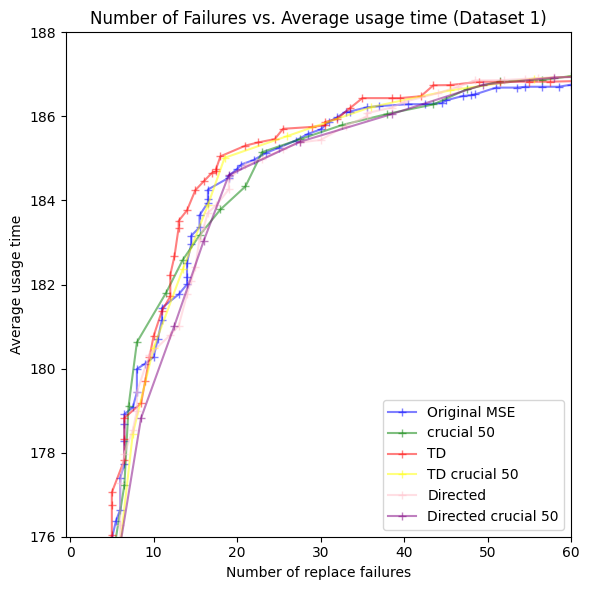

In [220]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, result_df in enumerate(result_dfs):
    ax.plot(
        result_df['Number of replace failures'],
        result_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(176,188) ### for dataset1

ax.set_xlim(-0.5,60)


# Show the plot
plt.tight_layout()
plt.show()

3번째 반복

In [224]:
train = sampled_data_list[2][0].copy()
valid = sampled_data_list[2][1].copy()
full_data = sampled_data_list[2][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.323872104372796, R2:0.6446938608716896
valid set RMSE:54.355389737307895, R2:0.4443527950133367
full data set RMSE:51.83626691431874, R2:0.47702947731739
train set RMSE:72.72994660371826, R2:-0.4244426649424222
valid set RMSE:93.5325711440948, R2:-0.6452793690351504
full data set RMSE:90.87418714364543, R2:-0.6072774585182938
[[ 51.22829413]
 [  0.        ]
 [ -7.62052807]
 [ -5.57984776]
 [-19.93270446]
 [  0.        ]
 [  5.77905664]
 [ 34.79833466]
 [ -6.64642258]
 [-24.99923444]
 [  0.        ]
 [-29.34229278]
 [ 47.23429839]
 [  1.38537819]
 [-15.87260487]
 [-17.93514922]
 [  0.        ]
 [ -6.63669798]
 [  0.        ]
 [  0.        ]
 [ 27.57934245]
 [ 32.49848918]]
(22, 1)
train set RMSE:38.36818459787937, R2:0.6035750888108244
valid set RMSE:55.209085298561824, R2:0.4267619504323169
full data set RMSE:52.81294060927043, R2:0.45713670965311515
[[ 9.17866873]
 [ 0.        ]
 [-1.40948235]
 [-2.09143014]
 [-3.1406686 ]
 [ 0.        ]
 [ 9.17866873]
 [ 9.84101436]

In [225]:
full_nan_counts_and_cost_df_lists

[[     Threshold  Number of replace failures  Total Cost  Average usage time
  0          -40                          89   48.104645              187.30
  1          -39                          88   47.624132              187.30
  2          -38                          87   47.156208              187.25
  3          -37                          86   46.675567              187.25
  4          -36                          86   46.675567              187.25
  ..         ...                         ...         ...                 ...
  126         86                           0    6.961849              143.64
  127         87                           0    7.085666              141.13
  128         88                           0    7.215528              138.59
  129         89                           0    7.311545              136.77
  130         90                           0    7.374631              135.60
  
  [131 rows x 4 columns],
       Threshold  Number of replace failures  T

In [226]:
result_dfs = []
number_of_samples = 3

# full_nan_counts_and_cost_df_lists의 첫 번째부터 number_of_samples 번째까지 데이터프레임을 반복문으로 처리
for col_idx in range(6):  # 열 인덱스 0부터 5까지
    # 더할 데이터프레임 초기화
    sum_df = full_nan_counts_and_cost_df_lists[0][col_idx].copy()

    # full_nan_counts_and_cost_df_lists의 첫 번째부터 number_of_samples 번째까지의 데이터프레임을 더합니다.
    for sample_idx in range(1, number_of_samples):
        sum_df += full_nan_counts_and_cost_df_lists[sample_idx][col_idx]

    # 데이터프레임을 샘플 수로 나눠서 평균을 계산합니다.
    result_df = sum_df / number_of_samples
    result_dfs.append(result_df)

# 결과를 리스트로 출력합니다.
result_dfs

[     Threshold  Number of replace failures  Total Cost  Average usage time
 0        -40.0                   84.333333   45.869455          187.293333
 1        -39.0                   82.666667   45.069248          187.293333
 2        -38.0                   82.333333   44.913273          187.276667
 3        -37.0                   81.666667   44.593222          187.276667
 4        -36.0                   81.000000   44.272177          187.276667
 ..         ...                         ...         ...                 ...
 126       86.0                    0.333333    8.154589          127.786667
 127       87.0                    0.333333    8.302600          125.636667
 128       88.0                    0.333333    8.411460          123.920000
 129       89.0                    0.333333    8.590737          121.620000
 130       90.0                    0.333333    8.713786          120.003333
 
 [131 rows x 4 columns],
      Threshold  Number of replace failures  Total Cost  Aver

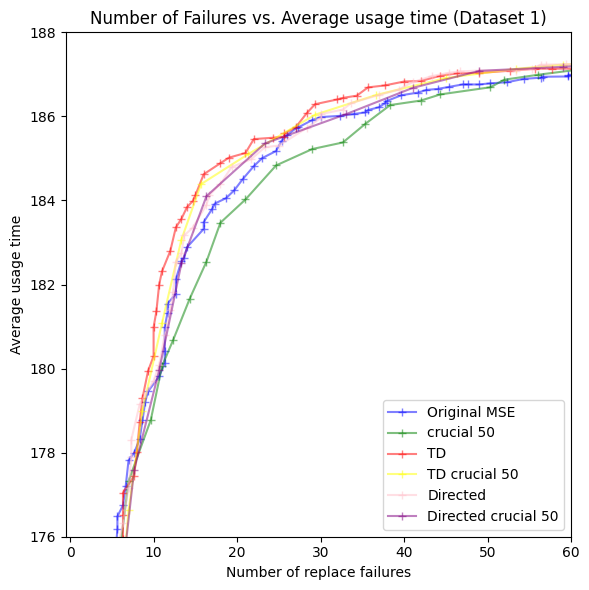

In [227]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, result_df in enumerate(result_dfs):
    ax.plot(
        result_df['Number of replace failures'],
        result_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(176,188) ### for dataset1

ax.set_xlim(-0.5,60)


# Show the plot
plt.tight_layout()
plt.show()

4번째 반복

In [228]:
train = sampled_data_list[3][0].copy()
valid = sampled_data_list[3][1].copy()
full_data = sampled_data_list[3][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:38.18921357643006, R2:0.6047945084353076
valid set RMSE:56.464017636267364, R2:0.4291725988039492
full data set RMSE:46.19309046595798, R2:0.5532399019059697
train set RMSE:75.21602694572735, R2:-0.533071179389897
valid set RMSE:98.02511563952477, R2:-0.7204259535080753
full data set RMSE:87.28744858685852, R2:-0.5952323136238957
[[ 66.67201539]
 [  0.        ]
 [-14.06025564]
 [ -6.13023516]
 [-13.5296927 ]
 [  0.        ]
 [  4.1471182 ]
 [ 32.1308573 ]
 [ -8.83506093]
 [-26.62313036]
 [  0.        ]
 [-15.48889173]
 [ 39.8734473 ]
 [  0.31187721]
 [-21.53810206]
 [-13.39820969]
 [  0.        ]
 [-20.5369823 ]
 [  0.        ]
 [  0.        ]
 [ 28.75685845]
 [ 31.03914009]]
(22, 1)
train set RMSE:40.179668227753425, R2:0.5625239993728437
valid set RMSE:57.952029377574334, R2:0.39868981990023633
full data set RMSE:49.069405918634025, R2:0.4958706994437524
[[ 9.65925596]
 [ 0.        ]
 [-1.17116247]
 [-1.53829106]
 [-3.79245785]
 [ 0.        ]
 [ 9.65925596]
 [ 9.063628

5번째 반복

In [229]:
train = sampled_data_list[4][0].copy()
valid = sampled_data_list[4][1].copy()
full_data = sampled_data_list[4][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.24681514580742, R2:0.6469000856695534
valid set RMSE:50.170420755806084, R2:0.5337744673855576
full data set RMSE:46.41071877998004, R2:0.5462131513632749
train set RMSE:72.07784140208722, R2:-0.39624441827951173
valid set RMSE:91.09097624234383, R2:-0.5369200642855378
full data set RMSE:82.82307283310828, R2:-0.445166862803833
[[ 54.53494997]
 [  0.        ]
 [-11.69112733]
 [ -5.65115364]
 [-19.39149105]
 [  0.        ]
 [  2.70896484]
 [ 40.42841297]
 [  7.65503089]
 [-35.84353317]
 [  0.        ]
 [-20.51302783]
 [ 45.1565177 ]
 [ -6.59317402]
 [-23.74871088]
 [-13.71826285]
 [  0.        ]
 [ -2.25729751]
 [  0.        ]
 [  0.        ]
 [ 24.75054127]
 [ 34.23777731]]
(22, 1)
train set RMSE:38.378231898572075, R2:0.6041525681318591
valid set RMSE:53.146419260752225, R2:0.47682306921597983
full data set RMSE:49.07360968694242, R2:0.49264572405472384
[[11.86928911]
 [ 0.        ]
 [-1.45794312]
 [-1.94900335]
 [-2.20122434]
 [ 0.        ]
 [ 8.8778008 ]
 [ 9.35941

6번째 반복

In [230]:
train = sampled_data_list[5][0].copy()
valid = sampled_data_list[5][1].copy()
full_data = sampled_data_list[5][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:35.292928299548514, R2:0.6570621169005977
valid set RMSE:50.16529480333518, R2:0.5213729680113286
full data set RMSE:45.817804405940215, R2:0.5384161133272293
train set RMSE:69.28719145136182, R2:-0.3217398689995816
valid set RMSE:89.8145255088648, R2:-0.5342058884455214
full data set RMSE:79.96361272365664, R2:-0.40594038548768374
[[ 59.46951756]
 [  0.        ]
 [ -5.19341999]
 [ -3.16655142]
 [-21.49965434]
 [  0.        ]
 [  5.02254764]
 [ 36.05740383]
 [ -2.37695159]
 [-30.67213705]
 [  0.        ]
 [-26.38842498]
 [ 37.93343402]
 [  1.00799399]
 [-23.64539176]
 [-17.40219554]
 [  0.        ]
 [-12.63505668]
 [  0.        ]
 [  0.        ]
 [ 33.7785647 ]
 [ 30.58296383]]
(22, 1)
train set RMSE:37.47735018084583, R2:0.6132967443079093
valid set RMSE:53.39203848973624, R2:0.4578200035991007
full data set RMSE:48.026157960508634, R2:0.4928484212193994
[[11.22001156]
 [ 0.        ]
 [-2.96071491]
 [-1.36978695]
 [-2.91748276]
 [ 0.        ]
 [11.22001156]
 [11.6994384

7번째 반복

In [231]:
train = sampled_data_list[6][0].copy()
valid = sampled_data_list[6][1].copy()
full_data = sampled_data_list[6][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.2179634395718, R2:0.6271531310615366
valid set RMSE:48.9841017982668, R2:0.5177219948769453
full data set RMSE:46.962803409718006, R2:0.5208236453623898
train set RMSE:74.20798917182849, R2:-0.4822676066599554
valid set RMSE:89.26681454510734, R2:-0.6016485787977635
full data set RMSE:86.01741392063522, R2:-0.6075338050378083
[[ 54.65263795]
 [  0.        ]
 [-15.71414355]
 [ -2.56724271]
 [-20.16940051]
 [  0.        ]
 [  3.83630918]
 [ 38.63624448]
 [ -5.29406678]
 [-33.17573563]
 [  0.        ]
 [-22.21895185]
 [ 42.74337951]
 [  2.56753148]
 [-26.89059859]
 [ -8.09007808]
 [  0.        ]
 [-11.97315542]
 [  0.        ]
 [  0.        ]
 [ 29.33337964]
 [ 32.1301107 ]]
(22, 1)
train set RMSE:39.19670856281891, R2:0.5864533660875961
valid set RMSE:50.69064969276415, R2:0.4835326482938007
full data set RMSE:49.5565881821966, R2:0.4664315407507361
[[10.09853318]
 [ 0.        ]
 [-4.18142729]
 [-3.34741912]
 [-2.68047523]
 [ 0.        ]
 [10.09853318]
 [10.27630853]
 [

8번째 반복

In [232]:
train = sampled_data_list[7][0].copy()
valid = sampled_data_list[7][1].copy()
full_data = sampled_data_list[7][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.30627644550553, R2:0.6213660121351339
valid set RMSE:51.53318529431799, R2:0.5144528463265454
full data set RMSE:45.04854782183657, R2:0.5554345956840181
train set RMSE:72.14675451589441, R2:-0.41608520734521304
valid set RMSE:90.24485686283138, R2:-0.48902626696419427
full data set RMSE:81.80365054517986, R2:-0.4659509574906695
[[ 52.51677405]
 [  0.        ]
 [ -1.36408431]
 [-12.35431392]
 [-16.21527789]
 [  0.        ]
 [  5.29759574]
 [ 44.64598979]
 [  3.27598331]
 [-27.8555851 ]
 [  0.        ]
 [-24.95927913]
 [ 45.01987576]
 [  1.00702416]
 [-21.99272816]
 [-13.20374984]
 [  0.        ]
 [ -9.30325353]
 [  0.        ]
 [  0.        ]
 [ 26.63505385]
 [ 27.13481414]]
(22, 1)
train set RMSE:39.170935021835255, R2:0.5825699939178002
valid set RMSE:54.09272791093332, R2:0.46502288396455793
full data set RMSE:47.74514398741156, R2:0.5006184572508279
[[10.14665098]
 [ 0.        ]
 [-1.47469728]
 [-1.58715694]
 [-3.23436333]
 [ 0.        ]
 [10.14665098]
 [ 9.864728

9번째 반복

In [233]:
train = sampled_data_list[8][0].copy()
valid = sampled_data_list[8][1].copy()
full_data = sampled_data_list[8][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.8667281729804, R2:0.6395963044364705
valid set RMSE:54.14608403747692, R2:0.4576968129836362
full data set RMSE:47.65816377646496, R2:0.5362510289268105
train set RMSE:74.37231189453696, R2:-0.4667044370659601
valid set RMSE:93.85785706506171, R2:-0.6294810693457242
full data set RMSE:84.72331443748159, R2:-0.46559583787805825
[[ 61.25813698]
 [  0.        ]
 [ -7.16667509]
 [-16.55171917]
 [-18.2429084 ]
 [  0.        ]
 [  5.46527343]
 [ 32.36710146]
 [ -0.69563572]
 [-30.11353607]
 [  0.        ]
 [-24.14768917]
 [ 43.9615565 ]
 [  0.58895975]
 [-26.67053232]
 [ -8.88743148]
 [  0.        ]
 [-13.16162978]
 [  0.        ]
 [  0.        ]
 [ 25.09934519]
 [ 36.47491345]]
(22, 1)
train set RMSE:39.12298954284533, R2:0.5941326563945419
valid set RMSE:54.998136195987406, R2:0.440494970196443
full data set RMSE:50.350236804848784, R2:0.4823796010114393
[[ 9.94690459]
 [ 0.        ]
 [-1.9148186 ]
 [-1.5877102 ]
 [-4.75281992]
 [ 0.        ]
 [ 9.94690459]
 [10.74463821]

10번째 반복

In [234]:
train = sampled_data_list[9][0].copy()
valid = sampled_data_list[9][1].copy()
full_data = sampled_data_list[9][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:35.815283835530025, R2:0.6404020043924407
valid set RMSE:56.92022464168862, R2:0.4552483561935291
full data set RMSE:45.85656175620442, R2:0.5472997910916912
train set RMSE:71.73374057532862, R2:-0.44253853491834194
valid set RMSE:94.81313521129277, R2:-0.5114798230622224
full data set RMSE:83.41371450140355, R2:-0.4978993743769011
[[ 60.99187717]
 [  0.        ]
 [-11.39852072]
 [ -6.97093178]
 [-12.46704646]
 [  0.        ]
 [  6.11624647]
 [ 35.23061449]
 [  5.48095111]
 [-29.41116379]
 [  0.        ]
 [-27.97893384]
 [ 45.73115772]
 [ -1.63362712]
 [-29.06166766]
 [-20.52735433]
 [  0.        ]
 [-13.19579552]
 [  0.        ]
 [  0.        ]
 [ 30.8219296 ]
 [ 23.25385462]]
(22, 1)
train set RMSE:37.897487284002366, R2:0.5973744792248155
valid set RMSE:58.98551745386022, R2:0.4149996500290063
full data set RMSE:48.14002720316183, R2:0.5010921014014222
[[ 9.90587813]
 [ 0.        ]
 [-0.784328  ]
 [-3.51651316]
 [-2.26474052]
 [ 0.        ]
 [ 9.19730442]
 [ 9.4935678

**최종 plot**

데이터 확인

In [235]:
full_nan_counts_and_cost_df_lists

[[     Threshold  Number of replace failures  Total Cost  Average usage time
  0          -40                          89   48.104645              187.30
  1          -39                          88   47.624132              187.30
  2          -38                          87   47.156208              187.25
  3          -37                          86   46.675567              187.25
  4          -36                          86   46.675567              187.25
  ..         ...                         ...         ...                 ...
  126         86                           0    6.961849              143.64
  127         87                           0    7.085666              141.13
  128         88                           0    7.215528              138.59
  129         89                           0    7.311545              136.77
  130         90                           0    7.374631              135.60
  
  [131 rows x 4 columns],
       Threshold  Number of replace failures  T

In [236]:
result_dfs = []
number_of_samples = 10

# full_nan_counts_and_cost_df_lists의 첫 번째부터 number_of_samples 번째까지 데이터프레임을 반복문으로 처리
for col_idx in range(6):  # 열 인덱스 0부터 5까지
    # 더할 데이터프레임 초기화
    sum_df = full_nan_counts_and_cost_df_lists[0][col_idx].copy()

    # full_nan_counts_and_cost_df_lists의 첫 번째부터 number_of_samples 번째까지의 데이터프레임을 더합니다.
    for sample_idx in range(1, number_of_samples):
        sum_df += full_nan_counts_and_cost_df_lists[sample_idx][col_idx]

    # 데이터프레임을 샘플 수로 나눠서 평균을 계산합니다.
    result_df = sum_df / number_of_samples
    result_dfs.append(result_df)

# 결과를 리스트로 출력합니다.
result_dfs

[     Threshold  Number of replace failures  Total Cost  Average usage time
 0        -40.0                        85.0   46.234442             187.119
 1        -39.0                        84.2   45.851818             187.113
 2        -38.0                        83.8   45.660772             187.108
 3        -37.0                        83.1   45.324080             187.108
 4        -36.0                        82.3   44.939651             187.108
 ..         ...                         ...         ...                 ...
 126       86.0                         0.2    7.902207             129.453
 127       87.0                         0.2    8.016836             127.663
 128       88.0                         0.2    8.138091             125.771
 129       89.0                         0.2    8.275914             123.765
 130       90.0                         0.1    8.319824             122.042
 
 [131 rows x 4 columns],
      Threshold  Number of replace failures  Total Cost  Aver

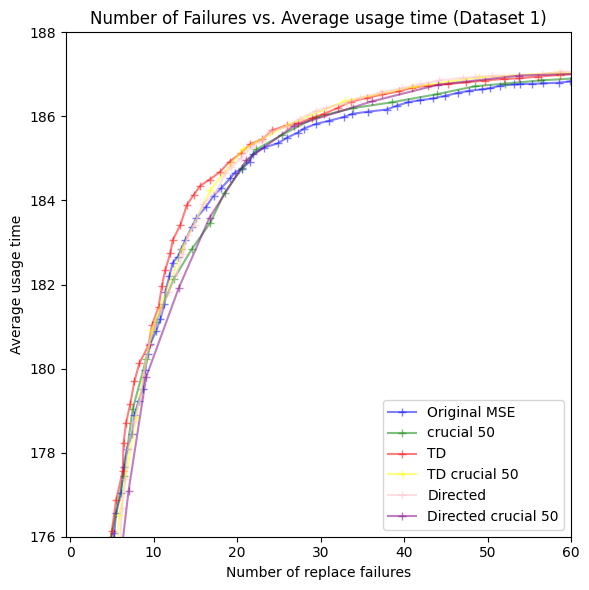

In [237]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, result_df in enumerate(result_dfs):
    ax.plot(
        result_df['Number of replace failures'],
        result_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(176,188) ### for dataset1

ax.set_xlim(-0.5,60)


# Show the plot
plt.tight_layout()
plt.show()

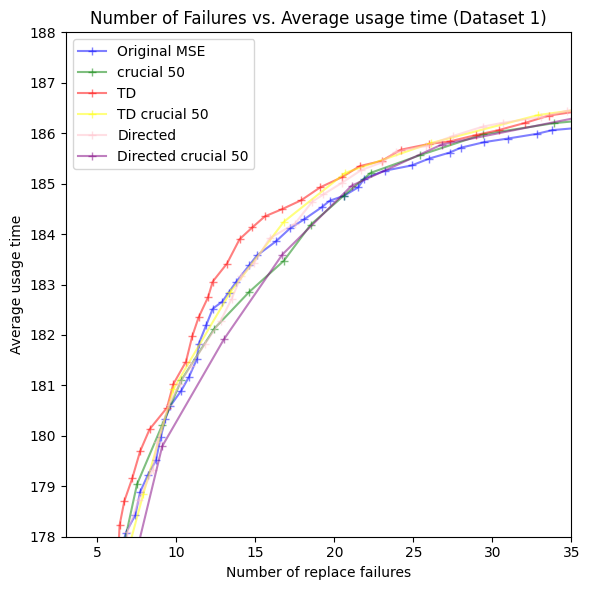

In [238]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, result_df in enumerate(result_dfs):
    ax.plot(
        result_df['Number of replace failures'],
        result_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(178,188) ### for dataset1

ax.set_xlim(3,35)


# Show the plot
plt.tight_layout()
plt.show()

학습된 데이터 프레임을 csv로 저장

In [239]:
# CSV 파일로 저장
for idx, df in enumerate(result_dfs, start=1):
    df.to_csv(f"result_df_{idx}.csv")